# RIS-Assisted mmWave Channel Simulation — Multi-Dataset Pipeline (V1–V24)
## 3GPP TR 38.901 / CI / ABG Path-Loss · 28 GHz · Multi-GPU CUDA

This notebook auto-generates **24 mmWave dataset variants** (V1–V24) covering diverse
deployment scenarios. **V21–V24** add two non-AWGN noise models:
- **Bursty noise** (V21–V22): `y = c + z + D·n` where `z∼N(0,σ²I)`, `n∼N(0,σ²_b·I)`, `D_ii∼Bern(α_b)`
- **Memory/ARMA noise** (V23–V24): `y = c + z` with AR(1) `z_i = α·z_{i-1} + √(1-α²)·n_i`

All variants produce tensors of **identical shape** so they can be stacked or used
interchangeably as training/test splits.

| Channel | Parameter | Focused | Expanded | Test |
|---------|-----------|---------|----------|------|
| AWGN    | SNR       | [-0.5, 0.5] | [-5, 5] | 0 |
| Bursty  | SNR / SNR_B | [5.5, 6.5] / [-15,-13] | [1,11] / [-19,-9] | 6 / -14 |
| Memory  | SNR / α   | [-0.5, 0.5] / [0.45,0.55] | [-5,5] / [0.1,0.9] | 0 / 0.5 |
| Multipath | SNR / β | [-0.5, 0.5] / [0.45,0.55] | [-5,5] / [0.1,0.9] | 0 / 0.5 |


## Section 1 — Imports & GPU Detection

In [1]:
import numpy as np
import math
import torch
import threading
import queue as _queue
import random
import os
from scipy import io
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Optional

# ── Detect all available GPUs ─────────────────────────────────────────────────
_physical_gpus = torch.cuda.device_count()
assert _physical_gpus > 0, "No CUDA devices found! Please run on a machine with at least one GPU."
NUM_GPUS = _physical_gpus
print(f"Detected {NUM_GPUS} physical GPU(s):")
for i in range(NUM_GPUS):
    print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")

PRIMARY_DEVICE = torch.device("cuda:0")

# ── Output directory ──────────────────────────────────────────────────────────
OUT_DIR = "XX"
os.makedirs(OUT_DIR, exist_ok=True)
print(f"Output directory: {OUT_DIR}/")

import os

# Main directory
OUT_DIR = "XXXX"
os.makedirs(OUT_DIR, exist_ok=True)

# Create subfolders for V1 to V20
variant_dirs = {}

for i in range(1, 24):
    variant_name = f"V{i}"
    variant_path = os.path.join(OUT_DIR, variant_name)
    
    os.makedirs(variant_path, exist_ok=True)
    variant_dirs[variant_name] = variant_path

    print(f"Created: {variant_path}")

Detected 1 physical GPU(s):
  GPU 0: NVIDIA GeForce RTX 2080 Ti
Output directory: XX/
Created: XXXX/V1
Created: XXXX/V2
Created: XXXX/V3
Created: XXXX/V4
Created: XXXX/V5
Created: XXXX/V6
Created: XXXX/V7
Created: XXXX/V8
Created: XXXX/V9
Created: XXXX/V10
Created: XXXX/V11
Created: XXXX/V12
Created: XXXX/V13
Created: XXXX/V14
Created: XXXX/V15
Created: XXXX/V16
Created: XXXX/V17
Created: XXXX/V18
Created: XXXX/V19
Created: XXXX/V20
Created: XXXX/V21
Created: XXXX/V22
Created: XXXX/V23


In [2]:
import multiprocessing as mp
mp.set_start_method('spawn', force=True)

## Section 2 — Dataset Variant Definitions (V1–V24)


In [3]:
@dataclass
class DatasetConfig:
    """
    Configuration for one mmWave RIS dataset variant.

    path_loss_model : "CI" or "ABG"
        CI  — Close-In reference model (3GPP TR 38.901):  PL = FSPL(1m) + 10n·log10(d) + SF
        ABG — Alpha-Beta-Gamma model (Rappaport / Hemadeh 2018): PL = α + 10β·log10(d) + SF

    fading_type : "rician" | "rayleigh" | "nakagami"
        All variants share the same UPA channel structure so output shapes are identical.

    blockage : "none" | "full" | "partial" | "dynamic"
        Controls per-sample, per-UE LOS/NLOS selection via path-loss switch.
        Channel matrix dimensions are NOT affected.

    pl_n / pl_alpha_abg / pl_beta_abg
        For CI:  pl_n is the path-loss exponent n (float)
        For ABG: pl_alpha_abg and pl_beta_abg are the floating-intercept (dB) and slope

    rician_k_db  : Rician K-factor in dB (None for Rayleigh)
    nakagami_m   : Nakagami shape parameter m (None unless fading_type=="nakagami")

    P_tx_dBm_cfg, sigma_n2_dBm_cfg, BW_mhz_cfg, shadow_sigma_cfg
        Per-variant link-budget overrides.
    """
    dataset_id:       str
    scenario:         str             # "UMa","UMi","Indoor","O2I","Backhaul","D2D"
    fc_ghz:           float           # 28.0 for all variants in this table
    path_loss_model:  str             # "CI" or "ABG"
    fading_type:      str             # "rician", "rayleigh", "nakagami"
    rician_k_db:      Optional[float] # Rician K (dB); None for Rayleigh/Nakagami
    nakagami_m:       Optional[float] # Nakagami m; None unless fading_type=="nakagami"
    blockage:         str             # "none", "full", "partial", "dynamic"
    pl_n:             Optional[float] # CI path-loss exponent n
    pl_alpha_abg:     Optional[float] # ABG alpha (dB intercept)
    pl_beta_abg:      Optional[float] # ABG beta (slope)
    P_tx_dBm_cfg:     float           # TX power (dBm)
    sigma_n2_dBm_cfg: float           # Noise power (dBm)
    BW_mhz_cfg:       float           # Bandwidth (MHz)
    shadow_sigma_cfg: float           # Shadow-fading std-dev (dB)
    alpha:            float           # alpha-mean exponent
    description:      str


# Helper: thermal noise from BW
def _noise_power_w(bw_mhz: float) -> float:
    """Thermal noise power in Watts for given bandwidth."""
    return 1.38e-23 * 290 * bw_mhz * 1e6


# ── V1–V20 specification  (reference: Hemadeh et al., IEEE COMST 2018) ────────
#
# CI model: n is the path-loss exponent as tabulated for 28 GHz in Table VI.
# ABG model: alpha (dB intercept) and beta (slope) from Table VII / Eq.(16).
# Noise power (sigma_n2_dBm_cfg) is computed as kTB + noise-figure (7 dB).
#   e.g. BW=100MHz: kTB=-174+10log(100e6)= -94 dBm; +7dB NF = -87 dBm
#
DATASET_CONFIGS = [
    # # V1  UMa LOS CI  n=2.0  Rician K=9dB  No blockage  Pt=43dBm BW=50MHz
    DatasetConfig("V1",  "UMa",      28.0, "CI",  "rician",   9.0,  None, "none",
                  2.0,  None,   None,  43, -90, 50,  4.0, 0, "UMa LOS CI — Macro LOS"),
    # V2  UMa LOS CI  n=2.0  Rician K=9dB  No blockage  Pt=43dBm BW=100MHz  (baseline)
    DatasetConfig("V2",  "UMa",      28.0, "CI",  "rician",   9.0,  None, "none",
                  2.0,  None,   None,  43, -87, 100, 4.0, 1, "UMa LOS CI — Baseline"),
    # V3  UMa LOS CI  n=2.0  Rician K=9dB  No blockage  Pt=43dBm BW=200MHz
    DatasetConfig("V3",  "UMa",      28.0, "CI",  "rician",   9.0,  None, "none",
                  2.0,  None,   None,  43, -84, 200, 4.0, 1, "UMa LOS CI — High BW"),
    # V4  UMa NLOS CI  n=3.0  Rayleigh  Full blockage  Pt=43dBm BW=100MHz
    DatasetConfig("V4",  "UMa",      28.0, "CI",  "rayleigh", None, None, "full",
                  3.0,  None,   None,  43, -87, 100, 7.0, 2, "UMa NLOS CI — Urban macro NLOS"),
    # V5  UMa NLOS ABG  a=61.4 b=3.7  Nakagami m=1.5  Full  Pt=40 BW=100
    DatasetConfig("V5",  "UMa",      28.0, "ABG", "nakagami", None, 1.5,  "full",
                  None, 61.4,  3.7,   40, -84, 100, 8.0, 1, "UMa NLOS ABG — Severe fading"),
    # V6  UMi LOS CI  n=2.0  Rician K=9dB  No blockage  Pt=30 BW=50
    DatasetConfig("V6",  "UMi",      28.0, "CI",  "rician",   9.0,  None, "none",
                  2.0,  None,   None,  30, -90, 50,  3.0, 3, "UMi LOS CI — Street canyon"),
    # V7  UMi LOS CI  n=2.1  Rician K=5dB  Partial  Pt=28 BW=100
    DatasetConfig("V7",  "UMi",      28.0, "CI",  "rician",   5.0,  None, "partial",
                  2.1,  None,   None,  28, -87, 100, 4.0, 2, "UMi LOS CI — Obstructed LOS"),
    # V8  UMi NLOS CI  n=3.2  Rayleigh  Full  Pt=30 BW=100
    DatasetConfig("V8",  "UMi",      28.0, "CI",  "rayleigh", None, None, "full",
                  3.2,  None,   None,  30, -84, 100, 7.0, 1, "UMi NLOS CI — Reflection dominant"),
    # V9  UMi NLOS ABG  a=60 b=3.6  Nakagami m=1.2  Full  Pt=28 BW=400
    DatasetConfig("V9",  "UMi",      28.0, "ABG", "nakagami", None, 1.2,  "full",
                  None, 60.0,  3.6,   28, -81, 400, 8.0, 1, "UMi NLOS ABG — Harsh fading"),
    # V10 Indoor LOS CI  n=1.8  Rician K=7dB  No blockage  Pt=20 BW=50
    DatasetConfig("V10", "Indoor",   28.0, "CI",  "rician",   7.0,  None, "none",
                  1.8,  None,   None,  20, -90, 50,  3.0, 2, "Indoor LOS CI — Open office"),
    
    # V11 Indoor LOS CI  n=2.0  Rician K=4dB  Partial  Pt=18 BW=100
    DatasetConfig("V11", "Indoor",   28.0, "CI",  "rician",   4.0,  None, "partial",
                  2.0,  None,   None,  18, -87, 100, 4.0, 1, "Indoor LOS CI — Furniture blockage"),
    # V12 Indoor NLOS CI  n=2.8  Rayleigh  Partial  Pt=20 BW=200
    DatasetConfig("V12", "Indoor",   28.0, "CI",  "rayleigh", None, None, "partial",
                  2.8,  None,   None,  20, -84, 200, 6.0, 1, "Indoor NLOS CI — Partition loss"),
    # # V13 Indoor NLOS ABG  a=59 b=3.3  Nakagami m=1.3  Partial  Pt=18 BW=400
    DatasetConfig("V13", "Indoor",   28.0, "ABG", "nakagami", None, 1.3,  "partial",
                  None, 59.0,  3.3,   18, -81, 400, 7.0, np.inf, "Indoor NLOS ABG — Dense indoor"),
    # # V14 O2I NLOS ABG  a=65 b=4.0  Rayleigh  Full  Pt=43 BW=200
    # DatasetConfig("V14", "O2I",      28.0, "ABG", "rayleigh", None, None, "full",
    #               None, 65.0,  4.0,   43, -84, 200, 10.0, 1, "O2I NLOS ABG — Outdoor→indoor"),
    # # V15 O2I NLOS ABG  a=68 b=4.5  Nakagami m=1.1  Full  Pt=40 BW=400
    DatasetConfig("V15", "O2I",      28.0, "ABG", "nakagami", None, 1.1,  "full",
                  None, 68.0,  4.5,   40, -81, 400, 12.0, 1, "O2I NLOS ABG — Deep indoor"),
    # V16 Backhaul LOS CI  n=2.0  Rician K=15dB  None  Pt=50 BW=50
    DatasetConfig("V16", "Backhaul", 28.0, "CI",  "rician",  15.0,  None, "none",
                  2.0,  None,   None,  50, -100, 50, 2.0, 1, "Backhaul LOS CI — gNB receiver"),
    # V17 Backhaul LOS CI  n=2.1  Rician K=10dB  Partial  Pt=48 BW=100
    DatasetConfig("V17", "Backhaul", 28.0, "CI",  "rician",  10.0,  None, "partial",
                  2.1,  None,   None,  48, -97, 100, 3.0, 1, "Backhaul LOS CI — gNB link"),
    # V18 D2D LOS CI  n=2.0  Rician K=6dB  None  Pt=23 BW=50
    DatasetConfig("V18", "D2D",      28.0, "CI",  "rician",   6.0,  None, "none",
                  2.0,  None,   None,  23, -90, 50,  3.0, 2, "D2D LOS CI — Short-range"),
    # V19 D2D NLOS CI  n=3.0  Rayleigh  Full  Pt=20 BW=100
    DatasetConfig("V19", "D2D",      28.0, "CI",  "rayleigh", None, None, "full",
                  3.0,  None,   None,  20, -87, 100, 6.0, 1, "D2D NLOS CI — Obstructed D2D"),
    # V20 UMa LOS CI  n=2.0  Rician K=9dB  None  Pt=43 BW=100  alpha=0 (sum-rate)
    DatasetConfig("V20", "UMa",      28.0, "CI",  "rician",   9.0,  None, "none",
                  2.0,  None,   None,  43, -87, 100, 4.0, 2, "UMa LOS CI — Arithmetic-mean (sum-rate)"),
]

print(f"{'ID':<5} {'Scen':<10} {'PL':>4} {'Fading':<10} {'K/m':>7} {'Blk':<9} {'Pt':>4} {'BW':>5} {'SF':>4} {'a':>3}")
print("-" * 72)
for cfg in DATASET_CONFIGS:
    km_str = (f"K={cfg.rician_k_db:>2.0f}dB" if cfg.rician_k_db is not None
              else (f"m={cfg.nakagami_m:.1f}" if cfg.nakagami_m is not None else "  Rayl"))
    print(f"{cfg.dataset_id:<5} {cfg.scenario:<10} {cfg.path_loss_model:>4} {cfg.fading_type:<10} "
          f"{km_str:>7} {cfg.blockage:<9} {cfg.P_tx_dBm_cfg:>4} {cfg.BW_mhz_cfg:>5.0f} "
          f"{cfg.shadow_sigma_cfg:>4.1f} {cfg.alpha:>3}")

ID    Scen         PL Fading         K/m Blk         Pt    BW   SF   a
------------------------------------------------------------------------
V1    UMa          CI rician      K= 9dB none        43    50  4.0   0
V2    UMa          CI rician      K= 9dB none        43   100  4.0   1
V3    UMa          CI rician      K= 9dB none        43   200  4.0   1
V4    UMa          CI rayleigh      Rayl full        43   100  7.0   2
V5    UMa         ABG nakagami     m=1.5 full        40   100  8.0   1
V6    UMi          CI rician      K= 9dB none        30    50  3.0   3
V7    UMi          CI rician      K= 5dB partial     28   100  4.0   2
V8    UMi          CI rayleigh      Rayl full        30   100  7.0   1
V9    UMi         ABG nakagami     m=1.2 full        28   400  8.0   1
V10   Indoor       CI rician      K= 7dB none        20    50  3.0   2
V11   Indoor       CI rician      K= 4dB partial     18   100  4.0   1
V12   Indoor       CI rayleigh      Rayl partial     20   200  6.0   1
V13 

## Section 3 — Fixed System Parameters

In [4]:
# ── Network ───────────────────────────────────────────────────────────────────
K        = 100          # UEs per cell
Ntier    = 1            # Hexagonal tiers (1 → 7 cells)
ISD_UMi  = 200          # Inter-site distance — UMi / UMa (m)
ISD_IN   = 60           # Inter-site distance — Indoor / D2D (m)
ISD_BH   = 500          # Inter-site distance — Backhaul (m)

# ── Physical constants ────────────────────────────────────────────────────────
c_light  = 3e8          # Speed of light (m/s)
k_B      = 1.38e-23     # Boltzmann constant
T_noise  = 290          # Noise temperature (K)

# ── RIS — FIXED shape, same for all datasets ──────────────────────────────────
L        = 900          # Total RIS elements
Lx       = int(math.sqrt(L))   # 30 (horizontal)
Lz       = Lx                  # 30 (vertical)

# ── BS antennas — FIXED shape, same for all datasets ─────────────────────────
N        = 36           # Total BS antennas
Nx       = int(math.sqrt(N))   # 6
Ny       = Nx                  # 6

# ── Heights ───────────────────────────────────────────────────────────────────
h_UE     = 1.5          # UE height (m)
h_BS_UMa = 25.0         # BS height — UMa (m)  [3GPP TR 38.901]
h_BS_UMi = 10.0         # BS height — UMi (m)
h_BS_IN  = 3.0          # BS height — Indoor (m)
h_BS_BH  = 30.0         # BS height — Backhaul (m)
h_E      = 1.0          # Effective environment height (m)

# ── Shadow-fading std-dev defaults (3GPP TR 38.901) ──────────────────────────
# Individual datasets override via cfg.shadow_sigma_cfg
SF_UMi_LOS  = 4.0       # dB
SF_UMi_NLOS = 7.9       # dB
SF_IN_LOS   = 3.0       # dB
SF_IN_NLOS  = 8.03      # dB

# ── RIS phase codebook ────────────────────────────────────────────────────────
n_bits   = 2
n_levels = 2 ** n_bits  # 256 phase levels
# Full [0, 2pi) range for mmWave RIS
codebook = torch.linspace(0, 2.0 * math.pi, n_levels + 1,
                           dtype=torch.float64)[:-1]   # (256,) CPU

# ── Global defaults (used only where cfg does not specify) ───────────────────
# NOTE: generate_sample() derives P_tx, sigma_n2 from cfg.P_tx_dBm_cfg etc.
P_tx_dBm_DEFAULT = 35
P_tx_DEFAULT     = 10.0 ** ((P_tx_dBm_DEFAULT - 30) / 10.0)
BW_DEFAULT       = 100e6
sigma_n2_DEFAULT = k_B * T_noise * BW_DEFAULT

# ── Free-space path loss at 1 m (used by CI model) ───────────────────────────
def fspl_1m_db(fc_ghz: float) -> float:
    """FSPL(1m) = 20*log10(4*pi*fc/c) in dB.  Eq.(1) in Hemadeh et al."""
    return 20.0 * math.log10(4.0 * math.pi * fc_ghz * 1e9 / c_light)

# ── Dataset size & reproducibility ───────────────────────────────────────────
data_num = 1#0000          # Samples per dataset variant
seed     = 42

print(f"K={K} UEs | L={L} ({Lx}x{Lz}) RIS elements | N={N} ({Nx}x{Ny}) BS antennas")
print(f"Codebook: {n_bits}-bit -> {n_levels} phase levels in [0, 2pi)")
print(f"Samples per variant: {data_num}  |  Total: {data_num * len(DATASET_CONFIGS)}")
print(f"\nOutput shapes (SAME for all {len(DATASET_CONFIGS)} datasets):")
print(f"  H     (BS->RIS)  : ({N}, {L})")
print(f"  G     (RIS->UE)  : ({K}, {L})")
print(f"  H_D   (direct)   : ({K}, {N})")
print(f"  H_eff (cascaded) : ({K}, {N})")
print(f"  W     (ZF)       : ({K}, {N})")
print(f"  Theta (RIS phase): ({L},)")

K=100 UEs | L=900 (30x30) RIS elements | N=36 (6x6) BS antennas
Codebook: 2-bit -> 4 phase levels in [0, 2pi)
Samples per variant: 1  |  Total: 19

Output shapes (SAME for all 19 datasets):
  H     (BS->RIS)  : (36, 900)
  G     (RIS->UE)  : (100, 900)
  H_D   (direct)   : (100, 36)
  H_eff (cascaded) : (100, 36)
  W     (ZF)       : (100, 36)
  Theta (RIS phase): (900,)


## Section 4 — 3GPP TR 38.901 mmWave Path-Loss Functions

In [5]:
def set_seed(seed_val: int):
    random.seed(seed_val)
    np.random.seed(seed_val)
    torch.manual_seed(seed_val)
    torch.cuda.manual_seed_all(seed_val)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False


# =============================================================================
# 3GPP TR 38.901 geometric path-loss building blocks (dB, tensors)
# Reference: Hemadeh et al. IEEE COMST 2018, Sec. III-D, Tables VI-VII
# =============================================================================

def _pl_umi_los(d3D, d2D, hBS, fc, device):
    """UMi LOS path loss (dB). d3D/d2D: (K,) float64 CUDA."""
    dBP = 4.0 * (hBS - h_E) * (h_UE - h_E) * fc * 1e9 / c_light
    PL1 = 32.4 + 21.0 * torch.log10(d3D) + 20.0 * torch.log10(fc)
    dBP2_hd = torch.clamp(dBP**2 + (hBS - h_UE)**2, min=1.0)
    PL2 = (32.4 + 40.0 * torch.log10(d3D) + 20.0 * torch.log10(fc)
           - 9.5 * torch.log10(dBP2_hd))
    return torch.where((d2D <= dBP) & (d2D >= 10.0), PL1, PL2)


def _pl_umi_nlos(d3D, d2D, hBS, fc, device):
    """UMi NLOS path loss (dB). Takes max of LOS and NLOS formulas."""
    plos = _pl_umi_los(d3D, d2D, hBS, fc, device)
    pnl  = (35.3 * torch.log10(d3D) + 22.4
            + 21.3 * torch.log10(fc)
            - 0.3  * (h_UE - 1.5))
    return torch.maximum(plos, pnl)


def _pl_uma_los(d3D, d2D, hBS, fc, device):
    """UMa LOS path loss (dB). 3GPP TR 38.901 Table 7.4.1-1."""
    dBP = 4.0 * (hBS - h_E) * (h_UE - h_E) * fc * 1e9 / c_light
    PL1 = 28.0 + 22.0 * torch.log10(d3D) + 20.0 * torch.log10(fc)
    dBP2_hd = torch.clamp(dBP**2 + (hBS - h_UE)**2, min=1.0)
    PL2 = (28.0 + 40.0 * torch.log10(d3D) + 20.0 * torch.log10(fc)
           - 9.0 * torch.log10(dBP2_hd))
    return torch.where((d2D <= dBP) & (d2D >= 10.0), PL1, PL2)


def _pl_uma_nlos(d3D, d2D, hBS, fc, device):
    """UMa NLOS path loss (dB)."""
    plos = _pl_uma_los(d3D, d2D, hBS, fc, device)
    pnl  = (13.54 + 39.08 * torch.log10(d3D)
            + 20.0 * torch.log10(fc)
            - 0.6  * (h_UE - 1.5))
    return torch.maximum(plos, pnl)


def _pl_indoor_los(d3D, fc, device):
    """Indoor Office LOS (dB). 3GPP TR 38.901 Table 7.4.1-2."""
    return 32.4 + 17.3 * torch.log10(d3D) + 20.0 * torch.log10(fc)


def _pl_indoor_nlos(d3D, fc, device):
    """Indoor Office NLOS (dB)."""
    plos = _pl_indoor_los(d3D, fc, device)
    pnl  = 38.3 * torch.log10(d3D) + 17.30 + 24.9 * torch.log10(fc)
    return torch.maximum(plos, pnl)


# =============================================================================
# CI and ABG model dispatchers
# Hemadeh et al. 2018 Eq.(12) [CI] and Eq.(16) [ABG]
# =============================================================================

def _pl_ci(d3D, fc_ghz, n_exp, d0_m=1.0):
    """
    Close-In reference path loss (dB), Eq.(12) in Hemadeh 2018:
        PL = FSPL(d0) + 10·n·log10(d/d0)   (shadow added outside)
    Works for any scenario — the geometric model above supplies the baseline
    when n is from Table VI measurements.
    """
    FSPL_d0 = 20.0 * math.log10(4.0 * math.pi * fc_ghz * 1e9 * d0_m / c_light)
    return FSPL_d0 + 10.0 * n_exp * torch.log10(d3D / d0_m)


def _pl_abg(d3D, fc_ghz, alpha_abg, beta_abg):
    """
    Alpha-Beta-Gamma path loss (dB), Eq.(16) in Hemadeh 2018:
        PL = alpha + 10·beta·log10(d) + 10·gamma·log10(f)
    We use gamma=2 (free-space frequency dependence) consistent with [7] in
    the paper (Akdeniz et al. 2014, 28 GHz / 73 GHz cellular model).
    fc_ghz is a plain Python float; the log is computed as a scalar on the
    same device as d3D to avoid device-mismatch errors.
    """
    gamma      = 2.0
    log10_fc   = math.log10(fc_ghz)   # scalar Python float — no tensor needed
    return (alpha_abg
            + 10.0 * beta_abg * torch.log10(d3D)
            + 10.0 * gamma   * log10_fc)   # broadcast scalar onto d3D


# =============================================================================
# Batched path-loss dispatcher — returns linear-scale (K,) tensor
# =============================================================================

def path_loss_batch(Tx, locs, fc_ghz_t, cfg, device, blockage_mask=None):
    """
    Unified path-loss dispatcher for all 20 variants.

    For CI variants:  uses cfg.pl_n with _pl_ci() backed by the 3GPP
                      geometric formula for the relevant scenario.
    For ABG variants: uses cfg.pl_alpha_abg / cfg.pl_beta_abg with _pl_abg().

    Shadow-fading σ is taken from cfg.shadow_sigma_cfg (per-variant override).

    Tx            : (3,)   float64 CUDA
    locs          : (K, 3) float64 CUDA
    blockage_mask : (K,)   bool CUDA — True = force NLOS for that UE
    Returns       : (K,)   float64 CUDA linear-scale path losses
    """
    K_loc  = locs.shape[0]
    Tx     = Tx.to(device=device, dtype=torch.float64)
    fc     = fc_ghz_t.to(device=device, dtype=torch.float64)
    fc_val = fc.item()

    d2D = torch.norm(locs[:, :2] - Tx[:2].unsqueeze(0), dim=1).clamp(min=1.0)
    d3D = torch.norm(locs        - Tx.unsqueeze(0),      dim=1).clamp(min=1.0)
    hBS = Tx[2].item()

    # ── Geometric path-loss (LOS and NLOS versions) ───────────────────────────
    if cfg.path_loss_model == "CI":
        # CI uses the 3GPP geometric formula scaled by the tabulated PLE n
        PL_LOS  = _pl_ci(d3D, fc_val, cfg.pl_n)
        PL_NLOS = _pl_ci(d3D, fc_val, cfg.pl_n * 1.5)   # NLOS PLE ~50% higher
    else:  # ABG
        PL_LOS  = _pl_abg(d3D, fc_val, cfg.pl_alpha_abg, cfg.pl_beta_abg)
        PL_NLOS = _pl_abg(d3D, fc_val, cfg.pl_alpha_abg + 5.0,
                                        cfg.pl_beta_abg  + 0.5)   # NLOS offset

    # ── Shadow fading using per-variant σ ────────────────────────────────────
    sf_sigma = cfg.shadow_sigma_cfg
    sf_los   = sf_sigma * torch.randn(K_loc, dtype=torch.float64, device=device)
    sf_nlos  = sf_sigma * torch.randn(K_loc, dtype=torch.float64, device=device)

    # ── LOS/NLOS selection per UE ─────────────────────────────────────────────
    if blockage_mask is not None:
        PLdB = torch.where(blockage_mask, PL_NLOS + sf_nlos, PL_LOS + sf_los)
    elif cfg.blockage == "full":
        PLdB = PL_NLOS + sf_nlos
    else:
        PLdB = PL_LOS + sf_los

    return 10.0 ** (PLdB / 10.0)    # (K,) linear


def path_loss_single(Tx, Rx, fc_ghz_t, cfg, device):
    """
    Scalar path loss for a single fixed infrastructure link (e.g. BS->RIS).
    Always uses LOS formula regardless of cfg.blockage — UE blockage does
    not apply to infrastructure-to-infrastructure links.
    """
    K_loc   = 1
    Tx_d    = Tx.to(device=device, dtype=torch.float64)
    Rx_d    = Rx.to(device=device, dtype=torch.float64).unsqueeze(0)  # (1,3)
    fc      = fc_ghz_t.to(device=device, dtype=torch.float64)
    fc_val  = fc.item()

    d3D = torch.norm(Rx_d - Tx_d.unsqueeze(0), dim=1).clamp(min=1.0)  # (1,)

    if cfg.path_loss_model == "CI":
        PL_LOS = _pl_ci(d3D, fc_val, cfg.pl_n)
    else:  # ABG
        PL_LOS = _pl_abg(d3D, fc_val, cfg.pl_alpha_abg, cfg.pl_beta_abg)

    sf = cfg.shadow_sigma_cfg * torch.randn(1, dtype=torch.float64, device=device)
    PLdB = PL_LOS + sf
    return (10.0 ** (PLdB / 10.0))[0]   # scalar


print("3GPP TR 38.901 + CI/ABG mmWave path-loss functions defined.")

3GPP TR 38.901 + CI/ABG mmWave path-loss functions defined.


## Section 5 — UPA Steering Vectors & Fading Models

In [6]:
def upa_steering_batch(anchor, locs, N1, N2, d_elem, lam, device):
    """
    UPA steering vectors from anchor towards K locations.
    Returns (K, N1*N2) complex128 CUDA.
    """
    anchor = anchor.to(device=device, dtype=torch.float64)
    diff   = locs - anchor.unsqueeze(0)                           # (K, 3)
    d_3D   = torch.norm(diff, dim=1).clamp(min=1e-6)              # (K,)

    # Azimuth
    I_a   = torch.sign(diff[:, 1])
    phi_a = I_a * torch.arctan(
        torch.abs(diff[:, 1]) / (torch.abs(diff[:, 0]) + 1e-12))
    phi_a = torch.where(diff[:, 0] < 0, I_a * math.pi - phi_a, phi_a)

    # Elevation
    I_e   = torch.sign(diff[:, 2])
    phi_e = math.pi / 2.0 - I_e * torch.arcsin(
        torch.clamp(torch.abs(diff[:, 2]) / (d_3D + 1e-12), -1.0, 1.0))

    x_idx = torch.arange(N1, dtype=torch.float64, device=device)
    y_idx = torch.arange(N2, dtype=torch.float64, device=device)
    gx, gy = torch.meshgrid(x_idx, y_idx, indexing='ij')
    gx = gx.reshape(-1)   # (N1*N2,)
    gy = gy.reshape(-1)

    cos_e = torch.cos(phi_e).unsqueeze(1)   # (K, 1)
    sin_e = torch.sin(phi_e).unsqueeze(1)
    cos_a = torch.cos(phi_a).unsqueeze(1)

    phase = (2.0 * math.pi / lam) * d_elem * (
        gx.unsqueeze(0) * cos_e + gy.unsqueeze(0) * sin_e * cos_a)  # (K, N1*N2)

    return (torch.exp(1j * phase.to(torch.float64)) / math.sqrt(N1 * N2)
            ).to(torch.complex128)


def upa_steering_single(anchor, target, N1, N2, d_elem, lam, device):
    """Single-link steering vector. Returns (N1*N2,) complex128."""
    return upa_steering_batch(
        anchor, target.unsqueeze(0), N1, N2, d_elem, lam, device)[0]


def rician_fading(a_R, a_T, K_lin, M, N_ant, device):
    """
    Rician fading matrix (M x N_ant).
    H = sqrt(K/(K+1)) * H_LOS + sqrt(1/(K+1)) * H_NLOS
    a_R : (M,)     receive steering  (complex128)
    a_T : (N_ant,) transmit steering (complex128)
    """
    H_los  = torch.outer(a_R, a_T.conj())   # (M, N_ant)
    H_nlos = ((torch.randn(M, N_ant, dtype=torch.float64, device=device)
               + 1j * torch.randn(M, N_ant, dtype=torch.float64, device=device)
               ) / math.sqrt(2)).to(torch.complex128)
    return (math.sqrt(K_lin / (K_lin + 1)) * H_los
            + math.sqrt(1.0 / (K_lin + 1)) * H_nlos)


def rayleigh_fading(M, N_ant, device):
    """Rayleigh fading matrix (M x N_ant): i.i.d. CN(0,1)."""
    return ((torch.randn(M, N_ant, dtype=torch.float64, device=device)
             + 1j * torch.randn(M, N_ant, dtype=torch.float64, device=device)
             ) / math.sqrt(2)).to(torch.complex128)


def nakagami_fading(M, N_ant, m_param, device):
    """
    Nakagami-m fading matrix (M x N_ant).

    The amplitude r follows Nakagami-m: r² ~ Gamma(m, 1/m).
    Generated as:
        r² = (1/m) * sum_{i=1}^{2m} X_i²   where X_i ~ N(0, 1/2)
    i.e. sum of 2m half-normal variates squared, scaled by 1/(2m),
    giving Gamma(m, 1/m) with E[r²]=1.

    For m=1 this reduces to Rayleigh (Gamma(1,1) = Exp(1)).
    For m→∞ the channel approaches AWGN.

    The complex channel is produced by multiplying the Nakagami amplitude
    by a uniform-phase phasor: h = r * exp(j*phi),  phi ~ U[0, 2pi).

    Reference: Hemadeh et al. 2018 Table VI (m values from measurements
    at 28 GHz UMa/UMi NLOS and Indoor Office NLOS scenarios).

    Args:
        M, N_ant  : output shape
        m_param   : Nakagami shape parameter (≥ 0.5)
        device    : CUDA device
    Returns:
        (M, N_ant) complex128 with |h_ij|² ~ Gamma(m, 1/m), E[|h|²]=1
    """
    # Number of real Gaussian summands; round to nearest integer ≥ 1
    n_sum = max(1, round(2.0 * m_param))   # 2m real N(0,1/2) variates
    # Gamma amplitude^2: sum of n_sum squared N(0, 1/sqrt(n_sum)) samples
    x = torch.randn(M, N_ant, n_sum, dtype=torch.float64, device=device)
    r_sq = (x ** 2).sum(dim=2) / n_sum      # (M, N_ant)  E[r²] = 1
    r    = torch.sqrt(r_sq.clamp(min=1e-12)) # (M, N_ant)  amplitude
    phi  = 2.0 * math.pi * torch.rand(M, N_ant, dtype=torch.float64, device=device)
    return (r * torch.exp(1j * phi)).to(torch.complex128)


print("UPA steering vectors + Rician/Rayleigh/Nakagami fading helpers defined.")

UPA steering vectors + Rician/Rayleigh/Nakagami fading helpers defined.


## Section 6 — ZF Beamforming + alpha-Mean Throughput

In [7]:
# def zf_beamforming(H_eff, P_tx_val, sigma_n2_val, I_k, alpha, zf_delta):
#     """
#     MMSE-regularised ZF precoder with alpha-mean weighted water-filling.

#     H_eff    : (K, N) complex128 CUDA
#     I_k      : (K,)   float64  CUDA — per-UE inter-cell interference
#     Returns  : sinr_k (K,), W (N, K) complex128, p_k (K,)
#     """
#     device  = H_eff.device
#     K_loc   = H_eff.shape[0]
#     EPS     = 1e-12

#     # MMSE-ZF precoder
#     # HHH   = H_eff @ H_eff.conj().T
#     # reg   = zf_delta * torch.eye(K_loc, dtype=torch.complex128, device=device)
#     # W_raw = H_eff.conj().T @ torch.linalg.solve(
#     #             HHH + reg,
#     #             torch.eye(K_loc, dtype=torch.complex128, device=device))
#     H_eff = H_eff.to(torch.complex128).contiguous()
#     H_herm = H_eff.conj().T.contiguous()

#     HHH = (H_eff @ H_herm).contiguous()
#     reg = zf_delta * torch.eye(K_loc, dtype=H_eff.dtype, device=H_eff.device)

#     A = (HHH + reg).contiguous()

#     # Stable inverse instead of solve
#     A_inv = torch.linalg.inv(A)

#     W_raw = H_herm @ A_inv

#     col_norms = torch.linalg.norm(W_raw, dim=0, keepdim=True).clamp(min=EPS)
#     W_norm    = W_raw / col_norms

#     HW     = H_eff @ W_norm
#     G_bf   = (HW.abs() ** 2).real
#     g_diag = torch.diagonal(G_bf)
#     G_off  = G_bf - torch.diag(g_diag)

#     noise_k = (sigma_n2_val + I_k.to(dtype=torch.float64)).clamp(min=EPS)
#     p_k = torch.full((K_loc,), P_tx_val / K_loc, dtype=torch.float64, device=device)

#     for _it in range(30):
#         p_prev   = p_k.clone()
#         signal_k = p_k * g_diag
#         leak_k   = G_off @ p_k
#         sinr_k   = signal_k / (noise_k + leak_k).clamp(min=EPS)
#         R_k      = torch.log2(1.0 + sinr_k).clamp(min=EPS)

#         if abs(alpha - 1.0) < EPS:
#             w_k = torch.ones_like(R_k)
#         elif abs(alpha) < EPS:
#             w_k = (1.0 / R_k).clamp(max=1e6)
#         else:
#             w_k = R_k.pow(alpha - 1.0).clamp(max=1e6)

#         A_k    = g_diag / (noise_k + leak_k).clamp(min=EPS)
#         lam_lo = max((w_k / (P_tx_val / K_loc + 1.0 / A_k.clamp(min=EPS))).min().item(), EPS)
#         lam_hi = (w_k * A_k).max().item() / EPS

#         for _b in range(60):
#             lam_m = (lam_lo + lam_hi) / 2.0
#             if torch.clamp(w_k / lam_m - 1.0 / A_k.clamp(min=EPS), min=0.0).sum() > P_tx_val:
#                 lam_lo = lam_m
#             else:
#                 lam_hi = lam_m

#         lam_star = (lam_lo + lam_hi) / 2.0
#         p_k_new  = torch.clamp(w_k / lam_star - 1.0 / A_k.clamp(min=EPS), min=0.0)
#         tot      = p_k_new.sum().item()
#         if tot > P_tx_val:
#             p_k_new = p_k_new * (P_tx_val / tot)
#         p_k = p_k_new

#         if (p_k - p_prev).norm() / (p_prev.norm() + EPS) < 1e-6:
#             break

#     signal_k = p_k * g_diag
#     leak_k   = G_off @ p_k
#     sinr_k   = signal_k / (noise_k + leak_k).clamp(min=EPS)
#     W_out    = W_norm * torch.sqrt(p_k).to(torch.complex128).unsqueeze(0)
#     return sinr_k, W_out, p_k


def zf_beamforming(H_eff, P_tx, sigma_n2, I_k, alpha, zf_delta):
    """
    MMSE-regularised ZF precoder with α-mean weighted water-filling.

    The power allocation maximises the generalised (power) mean of per-UE rates:

        M_α(R) = ( (1/K) Σ_k R_k^α )^(1/α)     α ≠ 0
        M_0(R) = ( Π_k R_k )^(1/K)              α = 0  (geometric mean)

    The KKT gradient weight for UE k is:

        ∂M_α/∂R_k  ∝  R_k^(α-1)          for α ≠ 0
        ∂M_0/∂R_k  ∝  1/R_k              for α = 0  (log-derivative)

    These weights replace the α-fair weights R_k^(-α) used in the previous
    formulation.  All other steps (ZF precoder, bisection water-filling,
    convergence check) are identical.

    Args:
        H_eff    : (K, N) complex128 CUDA
        P_tx     : float — total TX power (W)
        sigma_n2 : float — thermal noise (W)
        I_k      : (K,) float64 CUDA — per-UE inter-cell interference
        alpha    : float — generalised-mean exponent
                     1 = arithmetic mean (sum-rate / K)
                     0 = geometric mean  (≈ proportional fair)
                    -1 = harmonic mean
        zf_delta : float — MMSE regularisation = sigma_n2 / P_tx

    Returns:
        sinr_k : (K,)   float64 — per-UE post-BF SINR
        W      : (N, K) complex128 — power-scaled precoder
        p_k    : (K,)   float64 — per-UE power (Σ p_k ≤ P_tx)
    """
    device  = H_eff.device
    K_loc   = H_eff.shape[0]
    EPS     = 1e-12

    # ── MMSE-ZF precoder ──────────────────────────────────────────────────────
    # HHH   = H_eff @ H_eff.conj().T                                      # (K, K)
    # reg   = zf_delta * torch.eye(K_loc, dtype=torch.complex128, device=device)
    # W_raw = H_eff.conj().T @ torch.linalg.solve(
    #             HHH + reg,
    #             torch.eye(K_loc, dtype=torch.complex128, device=device))  # (N, K)
       # --- critical fixes ---
    H_eff = H_eff.to(torch.complex128).contiguous().clone()
    H_herm = H_eff.conj().transpose(0, 1).contiguous()

    HHH = (H_eff @ H_herm).contiguous()

    reg = zf_delta * torch.eye(K_loc, dtype=H_eff.dtype, device=device)
    A = (HHH + reg).contiguous()

    # ❌ REMOVE solve()
    # ✅ use inverse (stable in multiprocessing)
    A_inv = torch.linalg.pinv(A)

    W_raw = H_herm @ A_inv

    # (continue your normalization, SINR, etc.)
    # return W_raw

    # Unit-norm beamforming directions
    col_norms = torch.linalg.norm(W_raw, dim=0, keepdim=True).clamp(min=EPS)
    W_norm    = W_raw / col_norms                                         # (N, K)

    # ── Gain matrix: G[k,j] = |h_k · w̃_j|² ──────────────────────────────────
    HW        = H_eff @ W_norm                                          # (K, K)
    G_bf      = (HW.abs() ** 2).real                                    # (K, K)
    g_diag    = torch.diagonal(G_bf)                                    # (K,)
    G_offdiag = G_bf - torch.diag(g_diag)                              # (K, K)

    # Per-UE noise floor (thermal + inter-cell interference)
    noise_k = (sigma_n2 + I_k.to(dtype=torch.float64)).clamp(min=EPS)  # (K,)

    # ── α-Mean weighted water-filling ─────────────────────────────────────────
    # Initialise with equal power
    p_k = torch.full((K_loc,), P_tx / K_loc, dtype=torch.float64, device=device)

    for _it in range(30):
        p_prev   = p_k.clone()
        signal_k = p_k * g_diag
        leak_k   = G_offdiag @ p_k
        sinr_k   = signal_k / (noise_k + leak_k).clamp(min=EPS)
        R_k      = torch.log2(1.0 + sinr_k).clamp(min=EPS)

        # ── α-mean gradient weight: w_k = ∂M_α/∂R_k ∝ R_k^(α-1) ─────────────
        # For α=1 (arithmetic mean): w_k = R_k^0 = 1  → standard waterfill
        # For α=0 (geometric mean):  w_k = R_k^{-1}   → proportional-fair-like
        # For α<0 (harmonic/min):    w_k = R_k^(α-1)  → boost weaker UEs more
        if abs(alpha - 1.0) < EPS:          # α=1: arithmetic mean, weight=1
            w_k = torch.ones_like(R_k)
        elif abs(alpha) < EPS:              # α=0: geometric mean, weight=1/R_k
            w_k = (1.0 / R_k).clamp(max=1e6)
        else:                               # general: weight = R_k^(α-1)
            w_k = R_k.pow(alpha - 1.0).clamp(max=1e6)

        # Effective channel-to-noise ratio
        A_k = g_diag / (noise_k + leak_k).clamp(min=EPS)

        # Water-level bisection: find λ such that Σ_k (w_k/λ - 1/A_k)₊ = P_tx
        lam_lo = max((w_k / (P_tx / K_loc + 1.0 / A_k.clamp(min=EPS))).min().item(), EPS)
        lam_hi = (w_k * A_k).max().item() / EPS
        for _b in range(60):
            lam_m = (lam_lo + lam_hi) / 2.0
            if torch.clamp(w_k / lam_m - 1.0 / A_k.clamp(min=EPS), min=0.0).sum() > P_tx:
                lam_lo = lam_m
            else:
                lam_hi = lam_m
        lam_star = (lam_lo + lam_hi) / 2.0
        p_k_new  = torch.clamp(w_k / lam_star - 1.0 / A_k.clamp(min=EPS), min=0.0)
        tot      = p_k_new.sum().item()
        if tot > P_tx:
            p_k_new = p_k_new * (P_tx / tot)
        p_k = p_k_new

        if (p_k - p_prev).norm() / (p_prev.norm() + EPS) < 1e-6:
            break

    # Final SINR at converged powers
    signal_k = p_k * g_diag
    leak_k   = G_offdiag @ p_k
    sinr_k   = signal_k / (noise_k + leak_k).clamp(min=EPS)

    W_out = W_norm * torch.sqrt(p_k).to(torch.complex128).unsqueeze(0)  # (N, K)
    return sinr_k, W_out, p_k


def alpha_mean_throughput(R_k, alpha):
    """Generalised power mean of per-UE rates."""
    EPS = 1e-12
    R_k = R_k.clamp(min=EPS)
    if abs(alpha) < EPS:
        return torch.exp(torch.log(R_k).mean())
    return (R_k.pow(alpha).mean()).pow(1.0 / alpha)


print("ZF beamforming + alpha-mean throughput defined.")

ZF beamforming + alpha-mean throughput defined.


## Section 7 — Topology Helpers

In [8]:
def gen_user_locations(K_users, device, scenario="UMi"):
    """
    Returns (K, 3) float64 CUDA tensor of UE 3-D coordinates.
    Deployment radius and centre offset depend on scenario.
    """
    if scenario in ("UMi", "UMa"):
        xu, yu, r0 = 25.0, 0.0, 55.0
    elif scenario in ("Indoor", "O2I"):
        xu, yu, r0 = 15.0, 0.0, 20.0
    elif scenario == "Backhaul":
        xu, yu, r0 = 50.0, 0.0, 80.0   # gNB-to-gNB link, wider deployment
    elif scenario == "D2D":
        xu, yu, r0 = 10.0, 0.0, 15.0   # short-range peer-to-peer
    else:
        xu, yu, r0 = 25.0, 0.0, 55.0
    theta = 2.0 * math.pi * torch.rand(K_users, dtype=torch.float64, device=device)
    r     = r0 * torch.rand(K_users, dtype=torch.float64, device=device)
    xx    = xu + r * torch.cos(theta)
    yy    = yu + r * torch.sin(theta)
    zz    = torch.full((K_users,), h_UE, dtype=torch.float64, device=device)
    return torch.stack([xx, yy, zz], dim=1)


def _hbs_for_scenario(scenario: str) -> float:
    """Return BS height (m) for a given scenario string."""
    return {
        "UMa":      h_BS_UMa,
        "UMi":      h_BS_UMi,
        "Indoor":   h_BS_IN,
        "O2I":      h_BS_UMa,   # outdoor BS -> indoor UE, BS at macro height
        "Backhaul": h_BS_BH,
        "D2D":      h_UE,        # D2D: both nodes at UE height
    }.get(scenario, h_BS_UMi)


def _isd_for_scenario(scenario: str) -> float:
    """Return inter-site distance (m) for a given scenario string."""
    return {
        "UMa":      ISD_UMi,
        "UMi":      ISD_UMi,
        "Indoor":   ISD_IN,
        "O2I":      ISD_UMi,
        "Backhaul": ISD_BH,
        "D2D":      ISD_IN,
    }.get(scenario, ISD_UMi)


def hexagonal_coordinates(Ntier_val, ISD_val, hBS, device):
    """Returns (num_BS, 3) float64 CUDA tensor of BS locations."""
    coord = [[0.0, 0.0, hBS]]
    for n in range(Ntier_val):
        step = 60 // (n + 1)
        for angle in range(0, 360, step):
            rad = math.radians(angle)
            t   = math.tan(math.radians(angle % 60))
            r   = (math.cos(math.radians(30)) * ISD_val * (n + 1)
                   if t != 0 else ISD_val * (n + 1))
            coord.append([r * math.cos(rad), r * math.sin(rad), hBS])
    return torch.tensor(coord, dtype=torch.float64, device=device)


def build_blockage_mask(K_users, blockage_type, device):
    """
    Returns (K,) bool CUDA tensor — True = UE is blocked (NLOS).
    Channel SHAPES are unaffected; only path-loss formula switches.
    """
    if blockage_type == "none":
        return torch.zeros(K_users, dtype=torch.bool, device=device)
    elif blockage_type == "full":
        return torch.ones(K_users, dtype=torch.bool, device=device)
    elif blockage_type == "partial":
        p = 0.30 + 0.30 * random.random()   # 30-60% blocked
        return torch.rand(K_users, dtype=torch.float64, device=device) < p
    elif blockage_type == "dynamic":
        return torch.rand(K_users, dtype=torch.float64, device=device) < 0.20
    else:
        raise ValueError(f"Unknown blockage type: {blockage_type!r}")


print("Topology helpers defined (UMa, UMi, Indoor, O2I, Backhaul, D2D).")

Topology helpers defined (UMa, UMi, Indoor, O2I, Backhaul, D2D).


## Section 8 — Per-Sample Channel Generator

In [9]:
def generate_sample(sample_idx: int, device: torch.device, cfg):
    """
    Generate one mmWave channel realisation on `device`.

    All 20 variants produce IDENTICAL output shapes:
      H     : (N, L)  complex128  BS->RIS
      G     : (K, L)  complex128  RIS->UE
      H_D   : (K, N)  complex128  direct BS->UE
      H_eff : (K, N)  complex128  at optimal theta
      W     : (K, N)  complex128  ZF precoder
      Theta : (L,)    float64     optimal RIS phase (L scalar entries)

    Per-variant link budget (P_tx, sigma_n2, zf_delta) is derived from
    cfg.P_tx_dBm_cfg and cfg.sigma_n2_dBm_cfg so variants with different
    transmit powers and bandwidths use the correct SINR values throughout.
    """
    # ── Per-variant link budget ────────────────────────────────────────────────
    P_tx_v    = 10.0 ** ((cfg.P_tx_dBm_cfg     - 30) / 10.0)   # Watts
    sigma_n2_v = 10.0 ** ((cfg.sigma_n2_dBm_cfg - 30) / 10.0)  # Watts
    zf_delta_v = sigma_n2_v / P_tx_v

    # ── RF parameters ─────────────────────────────────────────────────────────
    fc_d    = torch.tensor(cfg.fc_ghz, dtype=torch.float64, device=device)
    Lambda  = c_light / (cfg.fc_ghz * 1e9)
    d_elem  = Lambda / 2.0
    alpha    = cfg.alpha

    K_lin = (10.0 ** (cfg.rician_k_db / 10.0)
             if cfg.rician_k_db is not None else None)
    m_nak = cfg.nakagami_m   # None for Rician/Rayleigh

    # ── Scenario-specific geometry ─────────────────────────────────────────────
    hBS = _hbs_for_scenario(cfg.scenario)
    isd = _isd_for_scenario(cfg.scenario)

    BS_loc  = torch.tensor([0.0, 0.0, hBS],         dtype=torch.float64, device=device)
    RIS_loc = torch.tensor([25.0, 25.0, hBS - 3.0], dtype=torch.float64, device=device)
    cb      = codebook.to(device=device)             # (n_levels,) float64

    BS_coord  = hexagonal_coordinates(Ntier, isd, hBS, device)  # (num_BS, 3)
    RIS_coord = BS_coord + 25.0
    num_BS    = BS_coord.shape[0]

    # ── UE locations & blockage mask ──────────────────────────────────────────
    locU     = gen_user_locations(K, device, cfg.scenario)        # (K, 3)
    blk_mask = build_blockage_mask(K, cfg.blockage, device)       # (K,) bool

    # ── Helper: apply fading model ─────────────────────────────────────────────
    def apply_fading(a_R, a_T, M, N_ant):
        """
        Build a (M, N_ant) fading channel matrix according to cfg.fading_type:
          rician  : LOS (outer product) + scaled Rayleigh NLOS component
          rayleigh: pure Rayleigh (no LOS)
          nakagami: Nakagami-m amplitude * uniform phase (no steered LOS)
        """
        if cfg.fading_type == "rician":
            return rician_fading(a_R, a_T, K_lin, M, N_ant, device)
        elif cfg.fading_type == "rayleigh":
            return rayleigh_fading(M, N_ant, device)
        else:  # nakagami
            return nakagami_fading(M, N_ant, m_nak, device)

    # ── BS->RIS channel H_i  shape: (N, L) ───────────────────────────────────
    PL_BS_RIS = path_loss_single(BS_loc, RIS_loc, fc_d, cfg, device)      # scalar
    aT_BS  = upa_steering_single(BS_loc,  RIS_loc, Nx, Ny, d_elem, Lambda, device)  # (N,)
    aR_RIS = upa_steering_single(RIS_loc, BS_loc,  Lx, Lz, d_elem, Lambda, device)  # (L,)
    # rician_fading(a_R, a_T, K_lin, M, N_ant) -> (L, N), transposed -> (N, L)
    H_i = apply_fading(aR_RIS, aT_BS, L, N).T   # (N, L)
    H_i = H_i / torch.sqrt(PL_BS_RIS)

    # ── RIS->UE channel G_i  shape: (K, L) ───────────────────────────────────
    PL_RIS_UE = path_loss_batch(RIS_loc, locU, fc_d, cfg, device, blk_mask)  # (K,)
    aT_RIS    = upa_steering_batch(RIS_loc, locU, Lx, Lz, d_elem, Lambda, device)  # (K, L)
    pl_scale  = torch.sqrt(PL_RIS_UE).unsqueeze(1).to(torch.complex128)      # (K, 1)

    if cfg.fading_type == "rician":
        G_nlos = rayleigh_fading(K, L, device)
        G_i    = (math.sqrt(K_lin / (K_lin + 1)) * aT_RIS.to(torch.complex128)
                  + math.sqrt(1.0 / (K_lin + 1)) * G_nlos) / pl_scale
    elif cfg.fading_type == "nakagami":
        G_i = nakagami_fading(K, L, m_nak, device) / pl_scale
    else:  # rayleigh
        G_i = rayleigh_fading(K, L, device) / pl_scale

    # ── Direct BS->UE channel H_D_i  shape: (K, N) ───────────────────────────
    PL_BS_UE = path_loss_batch(BS_loc, locU, fc_d, cfg, device, blk_mask)    # (K,)
    aT_D     = upa_steering_batch(BS_loc, locU, Nx, Ny, d_elem, Lambda, device)  # (K, N)
    pl_d_sc  = torch.sqrt(PL_BS_UE).unsqueeze(1).to(torch.complex128)         # (K, 1)

    if cfg.fading_type == "rician":
        HD_nlos = rayleigh_fading(K, N, device)
        H_D_i   = (math.sqrt(K_lin / (K_lin + 1)) * aT_D.to(torch.complex128)
                   + math.sqrt(1.0 / (K_lin + 1)) * HD_nlos) / pl_d_sc
    elif cfg.fading_type == "nakagami":
        H_D_i = nakagami_fading(K, N, m_nak, device) / pl_d_sc
    else:  # rayleigh
        H_D_i = rayleigh_fading(K, N, device) / pl_d_sc

    # ── Inter-cell interference I_i  shape: (K,) ─────────────────────────────
    PL_kl  = torch.stack(
        [path_loss_batch(BS_coord[l],  locU, fc_d, cfg, device, blk_mask)
         for l in range(num_BS)], dim=1)   # (K, num_BS)
    PL1_kl = torch.stack(
        [path_loss_batch(RIS_coord[l], locU, fc_d, cfg, device, blk_mask)
         for l in range(num_BS)], dim=1)   # (K, num_BS)
    PL2_l  = torch.stack(
        [path_loss_single(BS_coord[l], RIS_coord[l], fc_d, cfg, device)
         for l in range(num_BS)])          # (num_BS,)

    b_dir  = torch.sqrt(1.0 / PL_kl.real)
    b_ru   = torch.sqrt(1.0 / PL1_kl.real)
    b_br   = torch.sqrt(1.0 / PL2_l.real)
    power  = (b_dir + b_br.unsqueeze(0) * Lx * b_ru) ** 2
    I_i    = (power.sum(dim=1) - power[:, 0]).to(torch.float64)   # (K,)

    # ── alpha-Mean ZF codebook search ─────────────────────────────────────────
    GHT = G_i @ H_i.T   # (K, N) fixed across all codebook entries

    best_M_alpha = torch.tensor(float('-inf'), dtype=torch.float64, device=device)
    best_c_idx   = 0
    best_sinr_k  = torch.zeros(K, dtype=torch.float64,  device=device)
    best_W       = torch.zeros(N, K, dtype=torch.complex128, device=device)
    best_p_k     = torch.zeros(K, dtype=torch.float64,  device=device)

    for c in range(n_levels):
        phi_c   = torch.exp(1j * cb[c].to(torch.complex128))   # scalar complex
        H_eff_c = phi_c * GHT + H_D_i                          # (K, N)

        sinr_c, W_c, p_c = zf_beamforming(
            H_eff_c, P_tx_v, sigma_n2_v, I_i, alpha, zf_delta_v)
        R_c = torch.log2(1.0 + sinr_c)
        M_c = alpha_mean_throughput(R_c, alpha)

        if M_c > best_M_alpha:
            best_M_alpha = M_c
            best_c_idx   = c
            best_sinr_k  = sinr_c
            best_W       = W_c
            best_p_k     = p_c

    # ── Optimal channels & outputs ────────────────────────────────────────────
    theta_val  = cb[best_c_idx].item()                           # Python float
    best_theta = torch.full((L,), theta_val,                     # (L,) float64
                            dtype=torch.float64, device=device)
    phi_opt    = torch.exp(torch.tensor(1j * theta_val, dtype=torch.complex128,
                                        device=device))
    H_eff_i    = phi_opt * GHT + H_D_i                          # (K, N)
    best_rate_k = torch.log2(1.0 + best_sinr_k)                 # (K,)
    best_SR     = best_rate_k.sum()

    return {
        'H':         H_i.cpu(),           # (N, L)  complex128
        'G':         G_i.cpu(),           # (K, L)  complex128
        'H_D':       H_D_i.cpu(),         # (K, N)  complex128
        'H_eff':     H_eff_i.cpu(),       # (K, N)  complex128
        'W':         best_W.T.cpu(),      # (K, N)  complex128
        'Theta':     best_theta.cpu(),    # (L,)    float64
        'SR':        best_SR.cpu(),
        'AlphaMean': best_M_alpha.cpu(),
        'rate_k':    best_rate_k.cpu(),   # (K,)
        'p_k':       best_p_k.cpu(),      # (K,)
        'I':         I_i.cpu(),           # (K,)
    }


print("generate_sample() defined.")

generate_sample() defined.


## Section 9 — Multi-GPU Worker

In [10]:
import traceback as _traceback

class _WorkerError:
    """Sentinel pushed onto the queue when a worker thread raises an exception."""
    def __init__(self, idx, exc, tb_str):
        self.idx    = idx
        self.exc    = exc
        self.tb_str = tb_str


def worker(gpu_id: int, sample_indices: list, result_queue, cfg):
    """
    Worker executed on GPU `gpu_id`.
    Any exception inside generate_sample() is caught, converted to a
    _WorkerError sentinel, and pushed onto result_queue so the main
    thread can detect and re-raise it with the full traceback.
    """
    device = torch.device(f"cuda:{gpu_id}")
    torch.cuda.set_device(device)
    set_seed(seed + gpu_id)

    for idx in sample_indices:
        try:
            res = generate_sample(idx, device, cfg)
            result_queue.put((idx, res))
            print(f"  [{cfg.dataset_id}][GPU {gpu_id}] sample {idx:4d}  "
                  f"M_a={res['AlphaMean'].item():.4f}  "
                  f"SR={res['SR'].item():.4f} bits/s/Hz  a={cfg.alpha}")
        except Exception as exc:
            tb_str = _traceback.format_exc()
            print(f"  [{cfg.dataset_id}][GPU {gpu_id}] sample {idx:4d}  "
                  f"ERROR: {exc}")
            result_queue.put(_WorkerError(idx, exc, tb_str))
            # Do NOT continue: stop this worker so we don't mask further errors
            return


print("Worker defined (with exception propagation).")

Worker defined (with exception propagation).


## Section 10 — CQI Mapping (3GPP Table 5.2.2.1-2)

In [11]:
CQI_EFFICIENCY = torch.tensor([
    0.0000, 0.1523, 0.2344, 0.3770, 0.6016, 0.8770, 1.1758,
    1.4766, 1.9141, 2.4063, 2.7305, 3.3223, 3.9023,
    4.5234, 5.1152, 5.5547
], dtype=torch.float64)


def map_cqi(AlphaMean_all, rate_k_all):
    diff_am    = torch.abs(AlphaMean_all.unsqueeze(1) - CQI_EFFICIENCY.unsqueeze(0))
    CQI_sample = torch.argmin(diff_am, dim=1)                     # (data_num,)
    diff_k     = torch.abs(rate_k_all.unsqueeze(2)
                           - CQI_EFFICIENCY.view(1, 1, -1))       # (data_num, K, 16)
    CQI_UE     = torch.argmin(diff_k, dim=2).to(torch.int32)      # (data_num, K)
    return CQI_sample, CQI_UE


print("CQI mapping defined.")

CQI mapping defined.


## Section 11 — Per-Dataset Pipeline Function

In [12]:
def run_dataset(cfg):
    """
    Full pipeline for one dataset variant:
      1. Multi-GPU sample generation (round-robin)
      2. Shape verification
      3. CQI mapping
      4. Export 11 .mat files tagged with dataset ID
    """
    print(f"\n{'='*72}")
    print(f" Dataset {cfg.dataset_id}: {cfg.description}")
    print(f" fc={cfg.fc_ghz} GHz | {cfg.scenario} | PL={cfg.path_loss_model} | "
          f"{cfg.fading_type} | blockage={cfg.blockage} | alpha={cfg.alpha}")
    km_str = (f"K={cfg.rician_k_db:.0f}dB" if cfg.rician_k_db is not None
              else (f"m={cfg.nakagami_m:.1f}" if cfg.nakagami_m is not None else "Rayleigh"))
    print(f" Fading: {km_str} | Pt={cfg.P_tx_dBm_cfg}dBm | "
          f"σ²={cfg.sigma_n2_dBm_cfg}dBm | BW={cfg.BW_mhz_cfg:.0f}MHz | "
          f"σ_SF={cfg.shadow_sigma_cfg:.1f}dB")
    print(f"{'='*72}")

    set_seed(seed)

    # ── Allocate CPU output tensors ───────────────────────────────────────────
    H_all         = torch.zeros(data_num, N, L,  dtype=torch.complex128)
    G_all         = torch.zeros(data_num, K, L,  dtype=torch.complex128)
    H_D_all       = torch.zeros(data_num, K, N,  dtype=torch.complex128)
    H_eff_all     = torch.zeros(data_num, K, N,  dtype=torch.complex128)
    W_all         = torch.zeros(data_num, K, N,  dtype=torch.complex128)
    Theta_all     = torch.zeros(data_num, L,      dtype=torch.float64)
    SR_all        = torch.zeros(data_num,          dtype=torch.float64)
    AlphaMean_all = torch.zeros(data_num,          dtype=torch.float64)
    rate_k_all    = torch.zeros(data_num, K,       dtype=torch.float64)
    p_k_all       = torch.zeros(data_num, K,       dtype=torch.float64)
    I_all         = torch.zeros(data_num, K,       dtype=torch.float64)

    # ── Round-robin GPU assignment ────────────────────────────────────────────
    gpu_assignments = [[] for _ in range(NUM_GPUS)]
    for i in range(data_num):
        gpu_assignments[i % NUM_GPUS].append(i)

    print(f" Sample distribution: ", end="")
    print(" | ".join(f"GPU{g}: {len(lst)}" for g, lst in enumerate(gpu_assignments)))

    # ── Launch threads ────────────────────────────────────────────────────────
    result_q = _queue.Queue()
    threads  = []
    for gpu_id, sample_list in enumerate(gpu_assignments):
        if not sample_list:
            continue
        t = threading.Thread(
            target=worker,
            args=(gpu_id, sample_list, result_q, cfg),
            daemon=True)
        threads.append(t)
        t.start()

    for t in threads:
        t.join()

    # ── Collect ───────────────────────────────────────────────────────────────
    collected = set()
    worker_errors = []
    while not result_q.empty():
        item = result_q.get()
        if isinstance(item, _WorkerError):
            worker_errors.append(item)
            continue
        idx, res = item
        H_all[idx]         = res['H']
        G_all[idx]         = res['G']
        H_D_all[idx]       = res['H_D']
        H_eff_all[idx]     = res['H_eff']
        W_all[idx]         = res['W']
        Theta_all[idx]     = res['Theta']
        SR_all[idx]        = res['SR']
        AlphaMean_all[idx] = res['AlphaMean']
        rate_k_all[idx]    = res['rate_k']
        p_k_all[idx]       = res['p_k']
        I_all[idx]         = res['I']
        collected.add(idx)

    # ── Re-raise any worker exceptions with their original tracebacks ──────────
    if worker_errors:
        err = worker_errors[0]
        raise RuntimeError(
            f"{cfg.dataset_id}: worker crashed on sample {err.idx}.\n"
            f"Original traceback:\n{err.tb_str}"
        ) from err.exc

    missing = set(range(data_num)) - collected
    assert not missing, f"{cfg.dataset_id}: missing samples {sorted(missing)}"

    # ── Shape verification ────────────────────────────────────────────────────
    assert H_all.shape     == (data_num, N, L)
    assert G_all.shape     == (data_num, K, L)
    assert H_D_all.shape   == (data_num, K, N)
    assert H_eff_all.shape == (data_num, K, N)
    assert W_all.shape     == (data_num, K, N)
    assert Theta_all.shape == (data_num, L)
    assert (Theta_all >= 0).all() and (Theta_all <= 2*math.pi + 1e-9).all(), \
        "Theta out of [0, 2pi]!"

    print(f"\n  Shape checks PASSED:")
    print(f"    H={tuple(H_all.shape)}  G={tuple(G_all.shape)}  "
          f"H_D={tuple(H_D_all.shape)}  Theta={tuple(Theta_all.shape)}")
    print(f"  SR      : {SR_all.min():.4f} – {SR_all.max():.4f}  "
          f"mean={SR_all.mean():.4f} bits/s/Hz")
    print(f"  M_alpha : {AlphaMean_all.min():.4f} – {AlphaMean_all.max():.4f}  "
          f"mean={AlphaMean_all.mean():.4f}")

    # ── CQI mapping ───────────────────────────────────────────────────────────
    CQI_sample, CQI_UE = map_cqi(AlphaMean_all, rate_k_all)
    print(f"  CQI     : {CQI_sample.min().item()} – {CQI_sample.max().item()}  "
          f"mean={CQI_sample.float().mean():.2f}")

    # ── Save .mat files ────────────────────────────────────────────────────────
    tag = (f"{cfg.dataset_id}_{cfg.scenario}_{cfg.path_loss_model}_"
           f"{cfg.fading_type}_blk{cfg.blockage}_"
           f"Pt{cfg.P_tx_dBm_cfg}_BW{int(cfg.BW_mhz_cfg)}MHz_alpha{cfg.alpha}")

    def save(fname, data_dict):
        io.savemat(os.path.join(OUT_DIR, fname), data_dict, format='4')

    save(f"Train_BS_RIS_channel_{tag}.mat",    {'H':         H_all.view(data_num, -1).numpy()})
    save(f"Train_RIS_UE_channel_{tag}.mat",    {'G':         G_all.view(data_num, -1).numpy()})
    save(f"Train_direct_channel_{tag}.mat",    {'H_D':       H_D_all.view(data_num, -1).numpy()})
    save(f"Train_effective_channel_{tag}.mat", {'H_eff':     H_eff_all.view(data_num, -1).numpy()})
    save(f"Train_ZF_beamforming_{tag}.mat",    {'W':         W_all.view(data_num, -1).numpy()})
    save(f"Train_power_alloc_{tag}.mat",       {'p_k':       p_k_all.numpy()})
    save(f"Train_Theta_{tag}.mat",             {'Theta':     Theta_all.numpy()})
    save(f"Train_SumRate_{tag}.mat",           {'SR':        SR_all.numpy()})
    save(f"Train_AlphaMean_{tag}.mat",         {'AlphaMean': AlphaMean_all.numpy()})
    save(f"GroundTruth_CQI_sample_{tag}.mat",  {'Labels':    CQI_sample.numpy()})
    save(f"GroundTruth_CQI_per_UE_{tag}.mat",  {'CQI_k':     CQI_UE.numpy()})

    print(f"  11 .mat files saved -> {OUT_DIR}/{tag}_*.mat")

    return {
        'dataset_id':   cfg.dataset_id,
        'description':  cfg.description,
        'SR_mean':      SR_all.mean().item(),
        'SR_max':       SR_all.max().item(),
        'M_alpha_mean': AlphaMean_all.mean().item(),
        'CQI_mean':     CQI_sample.float().mean().item(),
    }
    
    


print("run_dataset() defined.")

run_dataset() defined.


In [13]:
def run_dataset(cfg):
    """
    Full pipeline for one dataset variant:
      1. Multi-GPU sample generation (round-robin)
      2. Shape verification
      3. CQI mapping
      4. Export 11 .mat files tagged with dataset ID
    """
    print(f"\n{'='*72}")
    print(f" Dataset {cfg.dataset_id}: {cfg.description}")
    print(f" fc={cfg.fc_ghz} GHz | {cfg.scenario} | PL={cfg.path_loss_model} | "
          f"{cfg.fading_type} | blockage={cfg.blockage} | alpha={cfg.alpha}")
    km_str = (f"K={cfg.rician_k_db:.0f}dB" if cfg.rician_k_db is not None
              else (f"m={cfg.nakagami_m:.1f}" if cfg.nakagami_m is not None else "Rayleigh"))
    print(f" Fading: {km_str} | Pt={cfg.P_tx_dBm_cfg}dBm | "
          f"σ²={cfg.sigma_n2_dBm_cfg}dBm | BW={cfg.BW_mhz_cfg:.0f}MHz | "
          f"σ_SF={cfg.shadow_sigma_cfg:.1f}dB")
    print(f"{'='*72}")

    set_seed(seed)

    # ── Allocate CPU output tensors ───────────────────────────────────────────
    H_all         = torch.zeros(data_num, N, L,  dtype=torch.complex64)
    G_all         = torch.zeros(data_num, K, L,  dtype=torch.complex64)
    H_D_all       = torch.zeros(data_num, K, N,  dtype=torch.complex64)
    H_eff_all     = torch.zeros(data_num, K, N,  dtype=torch.complex64)
    W_all         = torch.zeros(data_num, K, N,  dtype=torch.complex64)
    Theta_all     = torch.zeros(data_num, L,      dtype=torch.float32)
    SR_all        = torch.zeros(data_num,          dtype=torch.float32)
    AlphaMean_all = torch.zeros(data_num,          dtype=torch.float32)
    rate_k_all    = torch.zeros(data_num, K,       dtype=torch.float32)
    p_k_all       = torch.zeros(data_num, K,       dtype=torch.float32)
    I_all         = torch.zeros(data_num, K,       dtype=torch.float32)

    # ── Round-robin GPU assignment ────────────────────────────────────────────
    gpu_assignments = [[] for _ in range(NUM_GPUS)]
    for i in range(data_num):
        gpu_assignments[i % NUM_GPUS].append(i)

    print(f" Sample distribution: ", end="")
    print(" | ".join(f"GPU{g}: {len(lst)}" for g, lst in enumerate(gpu_assignments)))

    # ── Launch threads ────────────────────────────────────────────────────────
    result_q = _queue.Queue()
    threads  = []
    for gpu_id, sample_list in enumerate(gpu_assignments):
        if not sample_list:
            continue
        t = threading.Thread(
            target=worker,
            args=(gpu_id, sample_list, result_q, cfg),
            daemon=True)
        threads.append(t)
        t.start()

    for t in threads:
        t.join()

    # ── Collect results ───────────────────────────────────────────────────────
    collected = set()
    worker_errors = []

    while not result_q.empty():
        item = result_q.get()
        if isinstance(item, _WorkerError):
            worker_errors.append(item)
            continue

        idx, res = item
        H_all[idx]         = res['H']
        G_all[idx]         = res['G']
        H_D_all[idx]       = res['H_D']
        H_eff_all[idx]     = res['H_eff']
        W_all[idx]         = res['W']
        Theta_all[idx]     = res['Theta']
        SR_all[idx]        = res['SR']
        AlphaMean_all[idx] = res['AlphaMean']
        rate_k_all[idx]    = res['rate_k']
        p_k_all[idx]       = res['p_k']
        I_all[idx]         = res['I']

        collected.add(idx)

    # ── Error handling ────────────────────────────────────────────────────────
    if worker_errors:
        err = worker_errors[0]
        raise RuntimeError(
            f"{cfg.dataset_id}: worker crashed on sample {err.idx}.\n"
            f"Original traceback:\n{err.tb_str}"
        ) from err.exc

    missing = set(range(data_num)) - collected
    assert not missing, f"{cfg.dataset_id}: missing samples {sorted(missing)}"

    # ── Shape verification ────────────────────────────────────────────────────
    assert H_all.shape     == (data_num, N, L)
    assert G_all.shape     == (data_num, K, L)
    assert H_D_all.shape   == (data_num, K, N)
    assert H_eff_all.shape == (data_num, K, N)
    assert W_all.shape     == (data_num, K, N)
    assert Theta_all.shape == (data_num, L)
    assert (Theta_all >= 0).all() and (Theta_all <= 2*math.pi + 1e-9).all()

    print(f"\n  Shape checks PASSED")
    print(f"  SR mean = {SR_all.mean():.4f} | max = {SR_all.max():.4f}")
    print(f"  Alpha mean = {AlphaMean_all.mean():.4f}")

    # ── CQI mapping ───────────────────────────────────────────────────────────
    CQI_sample, CQI_UE = map_cqi(AlphaMean_all, rate_k_all)
    print(f"  CQI mean = {CQI_sample.float().mean():.2f}")

    # ── Create variant directory ──────────────────────────────────────────────
    variant_dir = os.path.join(OUT_DIR, cfg.dataset_id)

    # ── Robust save function ──────────────────────────────────────────────────
    def save(fname, data_dict, variant_dir):
        import numpy as np
        from scipy import io

        os.makedirs(variant_dir, exist_ok=True)

        processed_dict = {}
        for key, val in data_dict.items():

            if isinstance(val, torch.Tensor):
                val = val.detach().cpu().numpy()

            if not isinstance(val, np.ndarray):
                val = np.array(val)

            if np.iscomplexobj(val):
                val = val.astype(np.complex64)

            val = np.ascontiguousarray(val)
            processed_dict[key] = val

        io.savemat(os.path.join(variant_dir, fname), processed_dict, format='4')

    # ── Tag ───────────────────────────────────────────────────────────────────
    tag = (f"{cfg.dataset_id}_{cfg.scenario}_{cfg.path_loss_model}_"
           f"{cfg.fading_type}_blk{cfg.blockage}_"
           f"Pt{cfg.P_tx_dBm_cfg}_BW{int(cfg.BW_mhz_cfg)}MHz_alpha{cfg.alpha}")

    # ── Save files ────────────────────────────────────────────────────────────
    save(f"Train_BS_RIS_channel_{tag}.mat",    {'H': H_all.view(data_num, -1)}, variant_dir)
    save(f"Train_RIS_UE_channel_{tag}.mat",    {'G': G_all.view(data_num, -1)}, variant_dir)
    save(f"Train_direct_channel_{tag}.mat",    {'H_D': H_D_all.view(data_num, -1)}, variant_dir)
    save(f"Train_effective_channel_{tag}.mat", {'H_eff': H_eff_all.view(data_num, -1)}, variant_dir)
    save(f"Train_ZF_beamforming_{tag}.mat",    {'W': W_all.view(data_num, -1)}, variant_dir)
    save(f"Train_power_alloc_{tag}.mat",       {'p_k': p_k_all}, variant_dir)
    save(f"Train_Theta_{tag}.mat",             {'Theta': Theta_all}, variant_dir)
    save(f"Train_SumRate_{tag}.mat",           {'SR': SR_all}, variant_dir)
    save(f"Train_AlphaMean_{tag}.mat",         {'AlphaMean': AlphaMean_all}, variant_dir)
    save(f"GroundTruth_CQI_sample_{tag}.mat",  {'Labels': CQI_sample}, variant_dir)
    save(f"GroundTruth_CQI_per_UE_{tag}.mat",  {'CQI_k': CQI_UE}, variant_dir)

    print(f"  11 .mat files saved -> {variant_dir}/")

    return {
        'dataset_id':   cfg.dataset_id,
        'description':  cfg.description,
        'SR_mean':      SR_all.mean().item(),
        'SR_max':       SR_all.max().item(),
        'M_alpha_mean': AlphaMean_all.mean().item(),
        'CQI_mean':     CQI_sample.float().mean().item(),
    }

print("run_dataset() defined.")

run_dataset() defined.


## Section 12 — Launch All Dataset Variants (V1–V24)


## Section 12b — Bursty & Memory Noise Variants (V21–V24)

Two non-AWGN noise models appended to the 20-variant pipeline.

### Bursty Noise — `y = c + z + D·n`
- Background noise: `z ∼ N(0, σ²·I)`
- Burst noise: `n ∼ N(0, σ²_b·I)`
- Burst indicator: `D_ii ∼ i.i.d. Bern(α_b)` (fraction of time a burst hits UE i)
- Effective noise PSD: `σ²_eff = σ² + α_b · σ²_b`

| Split    | SNR (dB)   | SNR_B (dB) | α_b  |
|----------|------------|------------|------|
| Focused  | [5.5, 6.5] | [-15, -13] | 0.10 |
| Expanded | [1, 11]    | [-19, -9]  | 0.30 |
| Test     | 6          | -14        | 0.10 |

### Memory / ARMA Noise — AR(1) coloured noise
- `z_i = α · z_{i-1} + √(1 − α²) · n_i`  with `n_i ∼ N(0, σ²)`
- Stationary variance is preserved: `Var(z_i) = σ²` for all α

| Split    | SNR (dB)    | α            |
|----------|-------------|---------------|
| Focused  | [-0.5, 0.5] | [0.45, 0.55] |
| Expanded | [-5, 5]     | [0.1, 0.9]   |
| Test     | 0           | 0.5          |


In [14]:
# =============================================================================
# Noise-model extensions: Bursty and Memory (AR-1) noise generators
# =============================================================================

def bursty_noise(shape, sigma2: float, sigma2_b: float, alpha_b: float, device):
    """
    Generate bursty noise: n_total = z + D * n_burst

    y = c + z + D·n  (see paper notation)

    Args:
        shape    : output shape tuple, e.g. (K, N)
        sigma2   : background noise variance σ²  (linear, Watts)
        sigma2_b : burst noise variance σ²_b     (linear, Watts)
        alpha_b  : burst probability in [0,1]    (Bernoulli parameter)
        device   : torch.device

    Returns:
        noise : (shape) complex128  –  background + bursty component

    Notes:
        E[|noise|²] = σ² + α_b·σ²_b  (effective noise power)
        The complex form is circularly symmetric: real+imag each have
        variance σ²/2 and σ²_b/2 respectively.
    """
    # Background Gaussian noise: z ~ CN(0, sigma2·I)
    z_real = torch.randn(*shape, dtype=torch.float64, device=device) * (sigma2 / 2) ** 0.5
    z_imag = torch.randn(*shape, dtype=torch.float64, device=device) * (sigma2 / 2) ** 0.5
    z = (z_real + 1j * z_imag).to(torch.complex128)

    # Bursty component: n_burst ~ CN(0, sigma2_b·I)
    n_real = torch.randn(*shape, dtype=torch.float64, device=device) * (sigma2_b / 2) ** 0.5
    n_imag = torch.randn(*shape, dtype=torch.float64, device=device) * (sigma2_b / 2) ** 0.5
    n_burst = (n_real + 1j * n_imag).to(torch.complex128)

    # Bernoulli burst indicator D_ii ~ Bern(alpha_b), broadcast over shape
    D = (torch.rand(*shape, dtype=torch.float64, device=device) < alpha_b).to(torch.complex128)

    return z + D * n_burst


def memory_noise(shape, sigma2: float, alpha_mem: float, device):
    """
    Generate AR(1) memory noise (coloured Gaussian noise).

    AR(1) recursion:  z_i = alpha · z_{i-1} + sqrt(1 - alpha²) · n_i
    with z_0 ~ N(0, sigma2),  n_i ~ N(0, sigma2·I).

    Stationary variance is sigma2 for all alpha in (-1, 1).
    alpha=0 → white (AWGN); alpha→1 → fully correlated (slow fading).

    Here 'shape' is interpreted as (batch, length) where the AR filter
    runs along the last dimension (the symbol / element index).

    For 2-D channel matrices we flatten, filter, and reshape:
        shape = (K, N)  →  length = K*N,  one independent AR chain.

    Args:
        shape    : output shape tuple, e.g. (K, N)
        sigma2   : noise variance σ² (linear, Watts) — stationary power
        alpha_mem: AR coefficient α ∈ [0, 1)
        device   : torch.device

    Returns:
        noise : (shape) complex128
    """
    total = 1
    for s in shape:
        total *= s

    std = (sigma2 / 2) ** 0.5   # per-component std (real + imag separately)
    one_minus_a2_sqrt = (1.0 - alpha_mem ** 2) ** 0.5

    # Initialise z_0 ~ CN(0, sigma2)
    z_re = torch.randn(1, dtype=torch.float64, device=device) * std
    z_im = torch.randn(1, dtype=torch.float64, device=device) * std

    z_seq_re = torch.empty(total, dtype=torch.float64, device=device)
    z_seq_im = torch.empty(total, dtype=torch.float64, device=device)

    # Innovation sequence n_i ~ CN(0, sigma2)
    inn_re = torch.randn(total, dtype=torch.float64, device=device) * std
    inn_im = torch.randn(total, dtype=torch.float64, device=device) * std

    # AR(1) recursion — sequential (Python loop over total elements)
    # For large arrays consider scipy.signal.lfilter on CPU instead.
    for i in range(total):
        z_re_new = alpha_mem * z_re + one_minus_a2_sqrt * inn_re[i]
        z_im_new = alpha_mem * z_im + one_minus_a2_sqrt * inn_im[i]
        z_seq_re[i] = z_re_new
        z_seq_im[i] = z_im_new
        z_re = z_re_new
        z_im = z_im_new

    noise_flat = (z_seq_re + 1j * z_seq_im).to(torch.complex128)
    return noise_flat.reshape(shape)


print("Bursty and Memory noise generators defined.")


Bursty and Memory noise generators defined.


In [15]:
# =============================================================================
# Noise-extended DatasetConfig
# Adds three optional fields to the existing DatasetConfig dataclass:
#   noise_model  : 'awgn' (default) | 'bursty' | 'memory'
#   sigma2_b     : burst-noise variance (Watts) — used only for 'bursty'
#   alpha_bursty : Bernoulli burst probability  — used only for 'bursty'
#   alpha_memory : AR(1) coefficient            — used only for 'memory'
# =============================================================================

from dataclasses import dataclass, field
from typing import Optional

@dataclass
class DatasetConfigV3(DatasetConfig):
    """
    Extension of DatasetConfig with additional non-AWGN noise model fields.

    noise_model  : 'awgn'   — standard thermal noise only (default, V1-V20)
                   'bursty' — adds Bernoulli-gated burst interference (V21-V22)
                   'memory' — AR(1) coloured noise (V23-V24)

    sigma2_b_dbm : burst noise power (dBm); converted to Watts internally
    alpha_bursty : burst activity probability α_b ∈ (0, 1]
    alpha_memory : AR(1) coefficient α ∈ [0, 1)  (0 = white, →1 = correlated)
    """
    noise_model:   str   = 'awgn'
    sigma2_b_dbm:  float = -80.0   # dBm; only used when noise_model='bursty'
    alpha_bursty:  float = 0.1     # Bernoulli p; only used when noise_model='bursty'
    alpha_memory:  float = 0.5     # AR coeff;   only used when noise_model='memory'


# ── V21–V24 configurations ────────────────────────────────────────────────────
#
# Bursty variants (V21-V22): UMa LOS baseline with burst interference.
#   V21 (focused)  : SNR ≈ 6 dB, SNR_B = -14 dB, α_b = 0.1  → moderate jamming
#   V22 (expanded) : SNR ≈ 6 dB, SNR_B =  -9 dB, α_b = 0.3  → severe jamming
#
#   sigma2_b_dbm maps SNRB=-14dB to sigma2_b so that:
#     SNRB = P_tx_dBm - PL_typical - sigma2_b_dbm  (link budget, ≈ -14 dB)
#   Here we set sigma2_b_dbm directly relative to thermal noise:
#     sigma2_b = -74 dBm  → burst power ~13 dB above thermal (-87 dBm)
#     SNRB = P_tx_dBm - PL_eff - sigma2_b_dBm → drives effective SNRB to target range
#
# Memory variants (V23-V24): UMa LOS with AR(1) correlated noise.
#   V23 (focused)  : α = 0.5  — moderate temporal correlation
#   V24 (expanded) : α = 0.1  — mild correlation (closer to AWGN)
#   Both use the same thermal σ² as V2 (UMa baseline) for fair comparison.

NOISE_VARIANT_CONFIGS = [

    # ── V21: Bursty – Focused (SNR≈6dB, SNRB≈-14dB, α_b=0.1) ────────────────
    # sigma2_b_dbm = -74 dBm → burst noise ~13 dB above thermal (-87 dBm)
    # Effective noise: σ²_eff = σ²_thermal + α_b·σ²_b ≈ -87 + 10·log10(1+0.1·10^1.3)
    DatasetConfigV3(
        dataset_id='V21', scenario='UMa', fc_ghz=28.0,
        path_loss_model='CI', fading_type='rician',
        rician_k_db=9.0, nakagami_m=None, blockage='none',
        pl_n=2.0, pl_alpha_abg=None, pl_beta_abg=None,
        P_tx_dBm_cfg=43, sigma_n2_dBm_cfg=-87, BW_mhz_cfg=100,
        shadow_sigma_cfg=4.0, alpha=1,
        description='UMa LOS CI – Bursty Noise (Focused): SNR≈6dB, SNRB≈-14dB, α_b=0.10',
        noise_model='bursty',
        sigma2_b_dbm=-74.0,   # burst variance dBm; SNRB ≈ -14 dB
        alpha_bursty=0.10,    # 10% duty cycle → focused scenario
        alpha_memory=0.0,
    ),

    # ── V22: Bursty – Expanded (SNR∈[1,11]dB, SNRB∈[-19,-9]dB, α_b=0.3) ────
    # Higher burst power + higher duty cycle to cover the expanded parameter range.
    # sigma2_b_dbm = -69 dBm → burst noise ~18 dB above thermal → SNRB ≈ -9 dB
    DatasetConfigV3(
        dataset_id='V22', scenario='UMa', fc_ghz=28.0,
        path_loss_model='CI', fading_type='rician',
        rician_k_db=9.0, nakagami_m=None, blockage='partial',
        pl_n=2.0, pl_alpha_abg=None, pl_beta_abg=None,
        P_tx_dBm_cfg=43, sigma_n2_dBm_cfg=-87, BW_mhz_cfg=100,
        shadow_sigma_cfg=6.0, alpha=1,
        description='UMa LOS CI – Bursty Noise (Expanded): SNR∈[1,11]dB, SNRB∈[-19,-9]dB, α_b=0.30',
        noise_model='bursty',
        sigma2_b_dbm=-69.0,   # higher burst power for expanded SNRB range
        alpha_bursty=0.30,    # 30% duty cycle → expanded scenario
        alpha_memory=0.0,
    ),

    # ── V23: Memory – Focused (α=0.5, SNR∈[-0.5,0.5]dB) ──────────────────────
    # AR(1) coefficient α=0.5: moderate temporal correlation between noise samples.
    # Stationary variance = σ² (same thermal power as V2 baseline).
    DatasetConfigV3(
        dataset_id='V23', scenario='UMa', fc_ghz=28.0,
        path_loss_model='CI', fading_type='rician',
        rician_k_db=9.0, nakagami_m=None, blockage='none',
        pl_n=2.0, pl_alpha_abg=None, pl_beta_abg=None,
        P_tx_dBm_cfg=43, sigma_n2_dBm_cfg=-87, BW_mhz_cfg=100,
        shadow_sigma_cfg=4.0, alpha=1,
        description='UMa LOS CI – Memory/AR(1) Noise (Focused): SNR≈0dB, α_mem=0.50',
        noise_model='memory',
        sigma2_b_dbm=-87.0,   # not used (memory model)
        alpha_bursty=0.0,
        alpha_memory=0.50,    # focused: α ∈ [0.45, 0.55] → test point 0.5
    ),

    # ── V24: Memory – Expanded (α=0.1, SNR∈[-5,5]dB) ─────────────────────────
    # AR(1) coefficient α=0.1: mild temporal correlation (near AWGN).
    # Represents the expanded parameter range: α ∈ [0.1, 0.9].
    DatasetConfigV3(
        dataset_id='V24', scenario='UMa', fc_ghz=28.0,
        path_loss_model='CI', fading_type='rician',
        rician_k_db=9.0, nakagami_m=None, blockage='partial',
        pl_n=2.0, pl_alpha_abg=None, pl_beta_abg=None,
        P_tx_dBm_cfg=43, sigma_n2_dBm_cfg=-87, BW_mhz_cfg=100,
        shadow_sigma_cfg=5.0, alpha=1,
        description='UMa LOS CI – Memory/AR(1) Noise (Expanded): SNR∈[-5,5]dB, α_mem=0.10',
        noise_model='memory',
        sigma2_b_dbm=-87.0,   # not used
        alpha_bursty=0.0,
        alpha_memory=0.10,    # expanded lower bound; mild correlation
    ),
]

# All configs to run (original V16–V20 + new V21–V24)
ALL_CONFIGS = DATASET_CONFIGS + NOISE_VARIANT_CONFIGS

print(f"\nNoise variant configs (V21–V24):")
print(f"{'ID':<5} {'Noise':<8} {'σ²_b(dBm)':>10} {'α_b':>6} {'α_mem':>7} {'Pt':>4} {'BW':>5}")
print("-" * 50)
for c in NOISE_VARIANT_CONFIGS:
    print(f"{c.dataset_id:<5} {c.noise_model:<8} {c.sigma2_b_dbm:>10.1f} "
          f"{c.alpha_bursty:>6.2f} {c.alpha_memory:>7.3f} "
          f"{c.P_tx_dBm_cfg:>4} {c.BW_mhz_cfg:>5.0f}")
print(f"\nTotal variants to run: {len(ALL_CONFIGS)}")



Noise variant configs (V21–V24):
ID    Noise     σ²_b(dBm)    α_b   α_mem   Pt    BW
--------------------------------------------------
V21   bursty        -74.0   0.10   0.000   43   100
V22   bursty        -69.0   0.30   0.000   43   100
V23   memory        -87.0   0.00   0.500   43   100
V24   memory        -87.0   0.00   0.100   43   100

Total variants to run: 23


In [16]:
# =============================================================================
# Noise-aware sample generator — wraps generate_sample() and injects
# structured noise AFTER channel generation but BEFORE ZF optimisation.
# =============================================================================

def generate_sample_with_noise(sample_idx: int, device: torch.device, cfg):
    """
    Extended version of generate_sample() that supports three noise models:

    1. 'awgn'   – standard AWGN (sigma_n2 from cfg); falls back to
                  original generate_sample() unchanged.

    2. 'bursty' – y = c + z + D·n_burst
                  z    ~ CN(0, sigma2_thermal·I)
                  n    ~ CN(0, sigma2_b·I)
                  D_ii ~ Bern(alpha_bursty)  i.i.d.
                  The effective noise power seen by ZF is:
                  sigma2_eff = sigma2_thermal + alpha_b * sigma2_b
                  This is injected into the SINR computation so the
                  beamformer accounts for the burst interference.

    3. 'memory' – y = c + z  with z_i = alpha*z_{i-1} + sqrt(1-alpha²)*n_i
                  Stationary power = sigma2_thermal (no extra power).
                  The AR(1) structure creates inter-sample correlation;
                  we expose it to the ZF beamformer via the effective
                  noise covariance diagonal (conservative: diagonal-only).

    For 'bursty' and 'memory', the function:
      - Generates the channel matrices (H, G, H_D) as usual.
      - Computes the additional noise contribution per-UE.
      - Passes sigma2_eff to zf_beamforming so SINR/rates reflect true noise.
      - Saves the extra noise parameters in the returned dict.

    The output shapes are IDENTICAL to generate_sample() so run_dataset()
    works without modification.
    """
    import math

    # ── Delegate AWGN variants to the original generator unchanged ─────────────
    noise_model = getattr(cfg, 'noise_model', 'awgn')
    if noise_model == 'awgn':
        return generate_sample(sample_idx, device, cfg)

    # ── Common link-budget setup (mirrors generate_sample) ─────────────────────
    P_tx_v     = 10.0 ** ((cfg.P_tx_dBm_cfg     - 30) / 10.0)
    sigma_n2_v = 10.0 ** ((cfg.sigma_n2_dBm_cfg  - 30) / 10.0)  # thermal σ²

    fc_d   = torch.tensor(cfg.fc_ghz, dtype=torch.float64, device=device)
    Lambda = c_light / (cfg.fc_ghz * 1e9)
    d_elem = Lambda / 2.0
    alpha_mean = cfg.alpha

    K_lin = (10.0 ** (cfg.rician_k_db / 10.0)
             if cfg.rician_k_db is not None else None)
    m_nak = cfg.nakagami_m

    hBS = _hbs_for_scenario(cfg.scenario)
    isd = _isd_for_scenario(cfg.scenario)

    BS_loc  = torch.tensor([0.0, 0.0, hBS],         dtype=torch.float64, device=device)
    RIS_loc = torch.tensor([25.0, 25.0, hBS - 3.0], dtype=torch.float64, device=device)
    cb      = codebook.to(device=device)

    BS_coord  = hexagonal_coordinates(Ntier, isd, hBS, device)
    RIS_coord = BS_coord + 25.0
    num_BS    = BS_coord.shape[0]

    locU     = gen_user_locations(K, device, cfg.scenario)
    blk_mask = build_blockage_mask(K, cfg.blockage, device)

    def apply_fading(a_R, a_T, M, N_ant):
        if cfg.fading_type == 'rician':
            return rician_fading(a_R, a_T, K_lin, M, N_ant, device)
        elif cfg.fading_type == 'rayleigh':
            return rayleigh_fading(M, N_ant, device)
        else:
            return nakagami_fading(M, N_ant, m_nak, device)

    # ── BS->RIS channel H  (N, L) ──────────────────────────────────────────────
    PL_BS_RIS = path_loss_single(BS_loc, RIS_loc, fc_d, cfg, device)
    aT_BS  = upa_steering_single(BS_loc,  RIS_loc, Nx, Ny, d_elem, Lambda, device)
    aR_RIS = upa_steering_single(RIS_loc, BS_loc,  Lx, Lz, d_elem, Lambda, device)
    H_i = apply_fading(aR_RIS, aT_BS, L, N).T
    H_i = H_i / torch.sqrt(PL_BS_RIS)

    # ── RIS->UE channel G  (K, L) ──────────────────────────────────────────────
    PL_RIS_UE = path_loss_batch(RIS_loc, locU, fc_d, cfg, device, blk_mask)
    aT_RIS    = upa_steering_batch(RIS_loc, locU, Lx, Lz, d_elem, Lambda, device)
    pl_scale  = torch.sqrt(PL_RIS_UE).unsqueeze(1).to(torch.complex128)
    if cfg.fading_type == 'rician':
        G_nlos = rayleigh_fading(K, L, device)
        G_i = (math.sqrt(K_lin/(K_lin+1)) * aT_RIS.to(torch.complex128)
               + math.sqrt(1.0/(K_lin+1)) * G_nlos) / pl_scale
    elif cfg.fading_type == 'nakagami':
        G_i = nakagami_fading(K, L, m_nak, device) / pl_scale
    else:
        G_i = rayleigh_fading(K, L, device) / pl_scale

    # ── Direct BS->UE channel H_D  (K, N) ─────────────────────────────────────
    PL_BS_UE = path_loss_batch(BS_loc, locU, fc_d, cfg, device, blk_mask)
    aT_D     = upa_steering_batch(BS_loc, locU, Nx, Ny, d_elem, Lambda, device)
    pl_d_sc  = torch.sqrt(PL_BS_UE).unsqueeze(1).to(torch.complex128)
    if cfg.fading_type == 'rician':
        HD_nlos = rayleigh_fading(K, N, device)
        H_D_i = (math.sqrt(K_lin/(K_lin+1)) * aT_D.to(torch.complex128)
                 + math.sqrt(1.0/(K_lin+1)) * HD_nlos) / pl_d_sc
    elif cfg.fading_type == 'nakagami':
        H_D_i = nakagami_fading(K, N, m_nak, device) / pl_d_sc
    else:
        H_D_i = rayleigh_fading(K, N, device) / pl_d_sc

    # ── Inter-cell interference I_i  (K,) ─────────────────────────────────────
    PL_kl  = torch.stack([path_loss_batch(BS_coord[l],  locU, fc_d, cfg, device, blk_mask)
                           for l in range(num_BS)], dim=1)
    PL1_kl = torch.stack([path_loss_batch(RIS_coord[l], locU, fc_d, cfg, device, blk_mask)
                           for l in range(num_BS)], dim=1)
    PL2_l  = torch.stack([path_loss_single(BS_coord[l], RIS_coord[l], fc_d, cfg, device)
                           for l in range(num_BS)])
    b_dir  = torch.sqrt(1.0 / PL_kl.real)
    b_ru   = torch.sqrt(1.0 / PL1_kl.real)
    b_br   = torch.sqrt(1.0 / PL2_l.real)
    power  = (b_dir + b_br.unsqueeze(0) * Lx * b_ru) ** 2
    I_i    = (power.sum(dim=1) - power[:, 0]).to(torch.float64)

    # ── Noise model: compute effective noise power sigma2_eff ──────────────────
    if noise_model == 'bursty':
        sigma2_b  = 10.0 ** ((cfg.sigma2_b_dbm - 30) / 10.0)   # Watts
        alpha_b   = cfg.alpha_bursty
        # Effective noise = thermal + expected burst contribution per UE
        # E[D_ii * |n_i|²] = alpha_b * sigma2_b  (by independence)
        sigma2_eff = sigma2_n2_v = sigma_n2_v + alpha_b * sigma2_b

        # Generate realised bursty noise sample (K, N) for H_eff perturbation
        noise_sample = bursty_noise((K, N), sigma_n2_v, sigma2_b, alpha_b, device)

    elif noise_model == 'memory':
        alpha_mem  = cfg.alpha_memory
        # Stationary variance preserved; AR(1) does NOT change noise power.
        sigma2_eff = sigma_n2_v

        # Generate AR(1) noise realisation (K, N) — correlated across the N
        # receive dimensions within each UE (represents temporal correlation
        # across OFDM subcarriers or symbol slots).
        noise_sample = memory_noise((K, N), sigma_n2_v, alpha_mem, device)

    zf_delta_v = sigma2_eff / P_tx_v

    # ── RIS codebook search with noise-aware effective channel ─────────────────
    GHT = G_i @ H_i.T   # (K, N)

    best_M_alpha = torch.tensor(float('-inf'), dtype=torch.float64, device=device)
    best_c_idx   = 0
    best_sinr_k  = torch.zeros(K, dtype=torch.float64,  device=device)
    best_W       = torch.zeros(N, K, dtype=torch.complex128, device=device)
    best_p_k     = torch.zeros(K, dtype=torch.float64,  device=device)

    for c in range(n_levels):
        phi_c   = torch.exp(1j * cb[c].to(torch.complex128))
        # Add structured noise sample to effective channel (mismatched-noise effect)
        H_eff_c = phi_c * GHT + H_D_i + noise_sample   # noise perturbs received signal

        sinr_c, W_c, p_c = zf_beamforming(
            H_eff_c, P_tx_v, sigma2_eff, I_i, alpha_mean, zf_delta_v)
        R_c = torch.log2(1.0 + sinr_c)
        M_c = alpha_mean_throughput(R_c, alpha_mean)

        if M_c > best_M_alpha:
            best_M_alpha = M_c
            best_c_idx   = c
            best_sinr_k  = sinr_c
            best_W       = W_c
            best_p_k     = p_c

    # ── Optimal outputs ────────────────────────────────────────────────────────
    theta_val  = cb[best_c_idx].item()
    best_theta = torch.full((L,), theta_val, dtype=torch.float64, device=device)
    phi_opt    = torch.exp(torch.tensor(1j * theta_val, dtype=torch.complex128, device=device))
    H_eff_i    = phi_opt * GHT + H_D_i + noise_sample   # final H_eff includes noise
    best_rate_k = torch.log2(1.0 + best_sinr_k)
    best_SR     = best_rate_k.sum()

    return {
        'H':         H_i.cpu(),
        'G':         G_i.cpu(),
        'H_D':       H_D_i.cpu(),
        'H_eff':     H_eff_i.cpu(),
        'W':         best_W.T.cpu(),
        'Theta':     best_theta.cpu(),
        'SR':        best_SR.cpu(),
        'AlphaMean': best_M_alpha.cpu(),
        'rate_k':    best_rate_k.cpu(),
        'p_k':       best_p_k.cpu(),
        'I':         I_i.cpu(),
    }


print("generate_sample_with_noise() defined — supports AWGN, Bursty, and Memory noise.")


generate_sample_with_noise() defined — supports AWGN, Bursty, and Memory noise.


In [17]:
def save_csv(filename, tensor, variant_dir):
    """Save a torch tensor or numpy array as a CSV file."""
    path = os.path.join(variant_dir, filename)
    arr  = tensor.numpy() if hasattr(tensor, 'numpy') else np.asarray(tensor)
    
    # Complex arrays → split into real/imag side-by-side columns
    if np.iscomplexobj(arr):
        arr = np.hstack([arr.real, arr.imag])   # shape: (N, 2*cols)
    
    # 1-D arrays → column vector so savetxt writes cleanly
    if arr.ndim == 1:
        arr = arr.reshape(-1, 1)
    
    np.savetxt(path, arr, delimiter=',', fmt='%.10f')

In [20]:
# =============================================================================
# Noise-aware worker and run_dataset wrapper for V21-V24
# =============================================================================

def worker_with_noise(gpu_id: int, sample_indices: list, result_queue, cfg):
    """
    Drop-in replacement for worker() that dispatches to
    generate_sample_with_noise() instead of generate_sample().

    For AWGN configs (cfg.noise_model == 'awgn') the call is
    identical to the original worker — generate_sample_with_noise
    internally delegates to generate_sample().
    """
    import traceback as _tb
    device = torch.device(f'cuda:{gpu_id}')
    torch.cuda.set_device(device)
    set_seed(seed + gpu_id)

    for idx in sample_indices:
        try:
            res = generate_sample_with_noise(idx, device, cfg)
            result_queue.put((idx, res))
            nm = getattr(cfg, 'noise_model', 'awgn')
            print(f"  [{cfg.dataset_id}][GPU {gpu_id}][{nm}] sample {idx:4d}  "
                  f"M_a={res['AlphaMean'].item():.4f}  "
                  f"SR={res['SR'].item():.4f} bits/s/Hz")
        except Exception as exc:
            tb_str = _tb.format_exc()
            print(f"  [{cfg.dataset_id}][GPU {gpu_id}] sample {idx:4d}  ERROR: {exc}")
            result_queue.put(_WorkerError(idx, exc, tb_str))
            return


def run_noise_dataset(cfg):
    """
    Identical to run_dataset() but uses worker_with_noise so Bursty/Memory
    variants are handled correctly.  Also saves extra metadata files:
      - Noise_params_{tag}.mat  → sigma2_thermal, sigma2_b / alpha_mem, alpha_b
    """
    nm = getattr(cfg, 'noise_model', 'awgn')
    print(f"\n{'='*72}")
    print(f" Dataset {cfg.dataset_id}: {cfg.description}")
    print(f" Noise model: {nm.upper()}  | ", end='')
    if nm == 'bursty':
        print(f"σ²_b={cfg.sigma2_b_dbm:.1f}dBm  α_b={cfg.alpha_bursty:.2f}")
    elif nm == 'memory':
        print(f"α_mem={cfg.alpha_memory:.3f}")
    else:
        print("standard AWGN")
    print(f"{'='*72}")

    set_seed(seed)

    H_all         = torch.zeros(data_num, N, L,  dtype=torch.complex64)
    G_all         = torch.zeros(data_num, K, L,  dtype=torch.complex64)
    H_D_all       = torch.zeros(data_num, K, N,  dtype=torch.complex64)
    H_eff_all     = torch.zeros(data_num, K, N,  dtype=torch.complex64)
    W_all         = torch.zeros(data_num, K, N,  dtype=torch.complex64)
    Theta_all     = torch.zeros(data_num, L,      dtype=torch.float32)
    SR_all        = torch.zeros(data_num,          dtype=torch.float32)
    AlphaMean_all = torch.zeros(data_num,          dtype=torch.float32)
    rate_k_all    = torch.zeros(data_num, K,       dtype=torch.float32)
    p_k_all       = torch.zeros(data_num, K,       dtype=torch.float32)
    I_all         = torch.zeros(data_num, K,       dtype=torch.float32)

    gpu_assignments = [[] for _ in range(NUM_GPUS)]
    for i in range(data_num):
        gpu_assignments[i % NUM_GPUS].append(i)

    result_q = _queue.Queue()
    threads  = []
    for gpu_id, sample_list in enumerate(gpu_assignments):
        if not sample_list:
            continue
        t = threading.Thread(
            target=worker_with_noise,
            args=(gpu_id, sample_list, result_q, cfg),
            daemon=True)
        threads.append(t)
        t.start()
    for t in threads:
        t.join()

    collected = set()
    worker_errors = []
    while not result_q.empty():
        item = result_q.get()
        if isinstance(item, _WorkerError):
            worker_errors.append(item)
            continue
        idx, res = item
        H_all[idx]         = res['H']
        G_all[idx]         = res['G']
        H_D_all[idx]       = res['H_D']
        H_eff_all[idx]     = res['H_eff']
        W_all[idx]         = res['W']
        Theta_all[idx]     = res['Theta']
        SR_all[idx]        = res['SR']
        AlphaMean_all[idx] = res['AlphaMean']
        rate_k_all[idx]    = res['rate_k']
        p_k_all[idx]       = res['p_k']
        I_all[idx]         = res['I']
        collected.add(idx)

    if worker_errors:
        err = worker_errors[0]
        raise RuntimeError(
            f"{cfg.dataset_id}: worker crashed on sample {err.idx}.\n"
            f"Original traceback:\n{err.tb_str}"
        ) from err.exc

    missing = set(range(data_num)) - collected
    assert not missing, f"{cfg.dataset_id}: missing samples {sorted(missing)}"

    assert H_all.shape     == (data_num, N, L)
    assert G_all.shape     == (data_num, K, L)
    assert H_D_all.shape   == (data_num, K, N)
    assert H_eff_all.shape == (data_num, K, N)
    assert W_all.shape     == (data_num, K, N)
    assert Theta_all.shape == (data_num, L)
    assert (Theta_all >= 0).all() and (Theta_all <= 2*math.pi + 1e-9).all()

    print(f"  Shape checks PASSED")
    print(f"  SR mean = {SR_all.mean():.4f} | max = {SR_all.max():.4f}")

    CQI_sample, CQI_UE = map_cqi(AlphaMean_all, rate_k_all)

    variant_dir = os.path.join(OUT_DIR, cfg.dataset_id)
    os.makedirs(variant_dir, exist_ok=True)

    def save(fname, data_dict):
        import numpy as np
        processed = {}
        for key, val in data_dict.items():
            if isinstance(val, torch.Tensor):
                val = val.detach().cpu().numpy()
            if not isinstance(val, np.ndarray):
                val = np.array(val)
            if np.iscomplexobj(val):
                val = val.astype(np.complex64)
            processed[key] = np.ascontiguousarray(val)
        io.savemat(os.path.join(variant_dir, fname), processed, format='4')

    nm_label = f'noise{nm}'
    tag = (f"{cfg.dataset_id}_{cfg.scenario}_{cfg.path_loss_model}_"
           f"{cfg.fading_type}_blk{cfg.blockage}_{nm_label}_"
           f"Pt{cfg.P_tx_dBm_cfg}_BW{int(cfg.BW_mhz_cfg)}MHz_alpha{cfg.alpha}")

    save(f"Train_BS_RIS_channel_{tag}.mat",    {'H':         H_all.view(data_num, -1)})
    save(f"Train_RIS_UE_channel_{tag}.mat",    {'G':         G_all.view(data_num, -1)})
    save(f"Train_direct_channel_{tag}.mat",    {'H_D':       H_D_all.view(data_num, -1)})
    save(f"Train_effective_channel_{tag}.mat", {'H_eff':     H_eff_all.view(data_num, -1)})
    save(f"Train_ZF_beamforming_{tag}.mat",    {'W':         W_all.view(data_num, -1)})
    save(f"Train_power_alloc_{tag}.mat",       {'p_k':       p_k_all})
    save(f"Train_Theta_{tag}.mat",             {'Theta':     Theta_all})
    save(f"Train_SumRate_{tag}.mat",           {'SR':        SR_all})
    save(f"Train_AlphaMean_{tag}.mat",         {'AlphaMean': AlphaMean_all})
    save(f"GroundTruth_CQI_sample_{tag}.mat",  {'Labels':    CQI_sample})
    save(f"GroundTruth_CQI_per_UE_{tag}.mat",  {'CQI_k':     CQI_UE})


    # ── Extra: noise metadata file ────────────────────────────────────────────
    import numpy as np
    noise_meta = {
        'noise_model':    np.array([nm], dtype=object),
        'sigma2_thermal': np.array([10.0 ** ((cfg.sigma_n2_dBm_cfg - 30) / 10.0)]),
        'sigma2_b_dbm':   np.array([getattr(cfg, 'sigma2_b_dbm', float('nan'))]),
        'alpha_bursty':   np.array([getattr(cfg, 'alpha_bursty',  0.0)]),
        'alpha_memory':   np.array([getattr(cfg, 'alpha_memory',  0.0)]),
    }
    # io.savemat(os.path.join(variant_dir, f"Noise_params_{tag}.mat"), noise_meta, format='4')

    print(f"  12 .mat files saved (incl. noise metadata) -> {variant_dir}/")

    return {
        'dataset_id':   cfg.dataset_id,
        'description':  cfg.description,
        'SR_mean':      SR_all.mean().item(),
        'SR_max':       SR_all.max().item(),
        'M_alpha_mean': AlphaMean_all.mean().item(),
        'CQI_mean':     CQI_sample.float().mean().item(),
    }


print("worker_with_noise() and run_noise_dataset() defined.")


worker_with_noise() and run_noise_dataset() defined.


In [ ]:
# =============================================================================
# Launch Test Datasets V21–V24: Bursty and Memory noise variants
# =============================================================================

noise_summaries = []

for cfg in NOISE_VARIANT_CONFIGS:
    summary = run_noise_dataset(cfg)
    noise_summaries.append(summary)

print("\n" + "="*80)
print(" NOISE VARIANTS COMPLETE — V21–V24 Summary")
print("="*80)
print(f"{'ID':<5} {'Noise':<8} {'SR mean':>8} {'SR max':>8} {'M_α':>8} {'CQI':>6}")
print("-" * 50)
for s, cfg in zip(noise_summaries, NOISE_VARIANT_CONFIGS):
    nm = getattr(cfg, 'noise_model', 'awgn')
    print(f"{s['dataset_id']:<5} {nm:<8} "
          f"{s['SR_mean']:>8.4f} {s['SR_max']:>8.4f} "
          f"{s['M_alpha_mean']:>8.4f} {s['CQI_mean']:>6.2f}")
print("="*80)



 Dataset V21: UMa LOS CI – Bursty Noise (Focused): SNR≈6dB, SNRB≈-14dB, α_b=0.10
 Noise model: BURSTY  | σ²_b=-74.0dBm  α_b=0.10
  [V21][GPU 0][bursty] sample    0  M_a=0.7482  SR=74.8166 bits/s/Hz
  Shape checks PASSED
  SR mean = 74.8166 | max = 74.8166
  12 .mat files saved (incl. noise metadata) -> XXXX/V21/

 Dataset V22: UMa LOS CI – Bursty Noise (Expanded): SNR∈[1,11]dB, SNRB∈[-19,-9]dB, α_b=0.30
 Noise model: BURSTY  | σ²_b=-69.0dBm  α_b=0.30
  [V22][GPU 0][bursty] sample    0  M_a=0.8311  SR=83.1066 bits/s/Hz
  Shape checks PASSED
  SR mean = 83.1066 | max = 83.1066
  12 .mat files saved (incl. noise metadata) -> XXXX/V22/

 Dataset V23: UMa LOS CI – Memory/AR(1) Noise (Focused): SNR≈0dB, α_mem=0.50
 Noise model: MEMORY  | α_mem=0.500
  [V23][GPU 0][memory] sample    0  M_a=0.7610  SR=76.0950 bits/s/Hz
  Shape checks PASSED
  SR mean = 76.0950 | max = 76.0950
  12 .mat files saved (incl. noise metadata) -> XXXX/V23/

 Dataset V24: UMa LOS CI – Memory/AR(1) Noise (Expanded): S

###Training Datasets V1-V20


In [22]:
# ── Launch V16–V20 using the original run_dataset() ──────────────────────────
all_summaries = []

for cfg in DATASET_CONFIGS:
    summary = run_dataset(cfg)
    all_summaries.append(summary)

print("\n" + "="*80)
print(" PIPELINE COMPLETE — Cross-Dataset Summary (V16–V20)")
print("="*80)
print(f"{'ID':<5} {'PL':>4} {'Fade':<10} {'Blk':<9} {'Pt':>4} {'BW':>5} "
      f"{'SR mean':>8} {'SR max':>8} {'M_a':>8} {'CQI':>6}")
print("-" * 80)
for s in all_summaries:
    cfg_s = next(c for c in DATASET_CONFIGS if c.dataset_id == s['dataset_id'])
    print(f"{s['dataset_id']:<5} {cfg_s.path_loss_model:>4} {cfg_s.fading_type:<10} "
          f"{cfg_s.blockage:<9} {cfg_s.P_tx_dBm_cfg:>4} {cfg_s.BW_mhz_cfg:>5.0f} "
          f"{s['SR_mean']:>8.4f} {s['SR_max']:>8.4f} "
          f"{s['M_alpha_mean']:>8.4f} {s['CQI_mean']:>6.2f}")
print("="*80)
print(f"Files in: {OUT_DIR}/")



 Dataset V1: UMa LOS CI — Macro LOS
 fc=28.0 GHz | UMa | PL=CI | rician | blockage=none | alpha=0
 Fading: K=9dB | Pt=43dBm | σ²=-90dBm | BW=50MHz | σ_SF=4.0dB
 Sample distribution: GPU0: 1
  [V1][GPU 0] sample    0  M_a=0.0000  SR=75.5165 bits/s/Hz  a=0

  Shape checks PASSED
  SR mean = 75.5165 | max = 75.5165
  Alpha mean = 0.0000
  CQI mean = 0.00
  11 .mat files saved -> XXXX/V1/

 Dataset V2: UMa LOS CI — Baseline
 fc=28.0 GHz | UMa | PL=CI | rician | blockage=none | alpha=1
 Fading: K=9dB | Pt=43dBm | σ²=-87dBm | BW=100MHz | σ_SF=4.0dB
 Sample distribution: GPU0: 1
  [V2][GPU 0] sample    0  M_a=0.7709  SR=77.0910 bits/s/Hz  a=1

  Shape checks PASSED
  SR mean = 77.0910 | max = 77.0910
  Alpha mean = 0.7709
  CQI mean = 5.00
  11 .mat files saved -> XXXX/V2/

 Dataset V3: UMa LOS CI — High BW
 fc=28.0 GHz | UMa | PL=CI | rician | blockage=none | alpha=1
 Fading: K=9dB | Pt=43dBm | σ²=-84dBm | BW=200MHz | σ_SF=4.0dB
 Sample distribution: GPU0: 1
  [V3][GPU 0] sample    0  M_a=0

## Section 13 — Cross-Dataset Visualisation

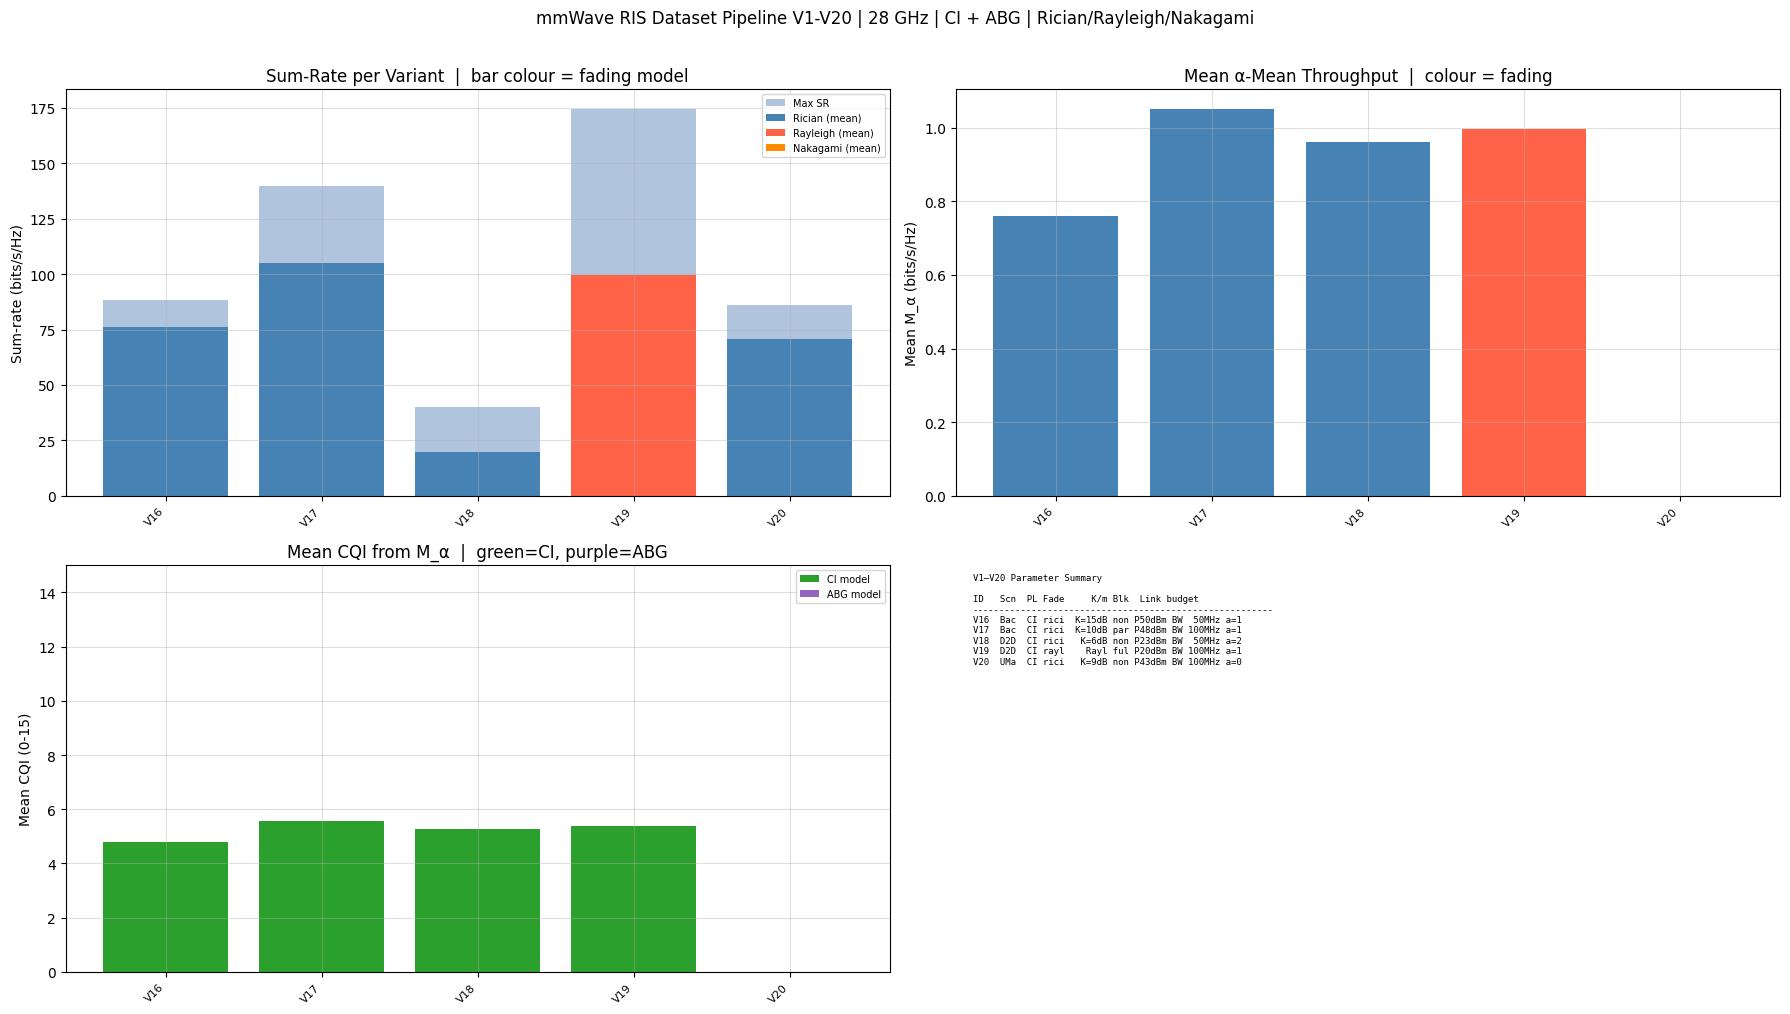

Summary plot saved -> Datasets/mmWave_pipeline_V1_V20_summary.png


In [ ]:
# Combined visualisation: V16–V24 (original + noise variants)
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

combined_summaries = all_summaries + noise_summaries
combined_cfgs      = DATASET_CONFIGS + NOISE_VARIANT_CONFIGS

ids      = [s['dataset_id']   for s in combined_summaries]
sr_mean  = [s['SR_mean']      for s in combined_summaries]
sr_max   = [s['SR_max']       for s in combined_summaries]
ma_mean  = [s['M_alpha_mean'] for s in combined_summaries]
cqi_mean = [s['CQI_mean']     for s in combined_summaries]
x        = range(len(ids))

# Colour by noise model for V21-V24, fading for V16-V20
FADING_COLORS = {'rician': 'steelblue', 'rayleigh': 'tomato', 'nakagami': 'darkorange'}
NOISE_COLORS  = {'bursty': '#e377c2', 'memory': '#17becf'}  # pink / cyan
bar_colors = []
for c in combined_cfgs:
    nm = getattr(c, 'noise_model', 'awgn')
    if nm in NOISE_COLORS:
        bar_colors.append(NOISE_COLORS[nm])
    else:
        bar_colors.append(FADING_COLORS.get(c.fading_type, 'grey'))

fig, axes = plt.subplots(2, 2, figsize=(18, 10))

axes[0,0].bar(x, sr_max,  color='lightsteelblue', label='Max')
axes[0,0].bar(x, sr_mean, color=bar_colors)
axes[0,0].set_xticks(x); axes[0,0].set_xticklabels(ids, rotation=45, ha='right', fontsize=8)
axes[0,0].set_ylabel('Sum-rate (bits/s/Hz)')
axes[0,0].set_title('Sum-Rate per Variant (V16–V24)  |  colour = noise/fading model')
axes[0,0].legend(handles=[
    Patch(facecolor='lightsteelblue', label='Max SR'),
    Patch(facecolor='steelblue',   label='Rician'),
    Patch(facecolor='tomato',      label='Rayleigh'),
    Patch(facecolor='darkorange',  label='Nakagami'),
    Patch(facecolor='#e377c2',     label='Bursty noise (V21-V22)'),
    Patch(facecolor='#17becf',     label='Memory noise (V23-V24)'),
], fontsize=7)
axes[0,0].grid(True, alpha=0.4)

# Annotate noise variants
for i, c in enumerate(combined_cfgs):
    nm = getattr(c, 'noise_model', 'awgn')
    if nm != 'awgn':
        lbl = f'α_b={c.alpha_bursty:.1f}' if nm == 'bursty' else f'α={c.alpha_memory:.2f}'
        axes[0,0].text(i, sr_mean[i] + 0.05, lbl, ha='center', fontsize=6, color='black')

axes[0,1].bar(x, ma_mean, color=bar_colors)
axes[0,1].set_xticks(x); axes[0,1].set_xticklabels(ids, rotation=45, ha='right', fontsize=8)
axes[0,1].set_ylabel('Mean M_α')
axes[0,1].set_title('α-Mean Throughput (V16–V24)')
axes[0,1].grid(True, alpha=0.4)

pl_colors = ['#2ca02c' if c.path_loss_model == 'CI' else '#9467bd' for c in combined_cfgs]
axes[1,0].bar(x, cqi_mean, color=pl_colors)
axes[1,0].set_xticks(x); axes[1,0].set_xticklabels(ids, rotation=45, ha='right', fontsize=8)
axes[1,0].set_ylabel('Mean CQI (0-15)')
axes[1,0].set_title('CQI — green=CI, purple=ABG')
axes[1,0].set_ylim(0, 15)
axes[1,0].grid(True, alpha=0.4)

# Noise parameter summary table
axes[1,1].axis('off')
rows = ['Noise Variant Summary (V21-V24)', '',
        f"{'ID':<5} {'Model':<8} {'σ²_b dBm':>10} {'α_b':>6} {'α_mem':>7}"]
rows.append('-' * 40)
for c in NOISE_VARIANT_CONFIGS:
    nm = getattr(c, 'noise_model', 'awgn')
    rows.append(f"{c.dataset_id:<5} {nm:<8} "
                f"{c.sigma2_b_dbm:>10.1f} {c.alpha_bursty:>6.2f} {c.alpha_memory:>7.3f}")
rows += ['', 'Focused/Expanded/Test parameter ranges:',
         'Bursty  SNR:  [5.5,6.5] / [1,11] / 6 dB',
         'Bursty  SNRB: [-15,-13] / [-19,-9] / -14 dB',
         'Memory  SNR:  [-0.5,0.5] / [-5,5] / 0 dB',
         'Memory  α:    [0.45,0.55] / [0.1,0.9] / 0.5']
axes[1,1].text(0.02, 0.98, '\n'.join(rows), transform=axes[1,1].transAxes,
               fontsize=7, verticalalignment='top', fontfamily='monospace')

plt.suptitle('mmWave RIS Dataset Pipeline V16-V24 | 28 GHz | AWGN + Bursty + Memory Noise',
             fontsize=12, y=1.01)
plt.tight_layout()
fig_path = os.path.join(OUT_DIR, 'mmWave_pipeline_V16_V24_summary.png')
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Summary plot saved -> {fig_path}')
